In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

import pandas as pd
import matplotlib.pyplot as plt

engine = create_mysql_engine()

templates_query = 'SELECT * FROM gophish.templates;'
df_templates = pd.read_sql( templates_query, engine )
df_templates.head(10)

,id,user_id,name,subject,text,html,modified_date,envelope_sender
0,1,1,Verificacion de acceso institucional,Verificacion urgente de acceso institucional,Asunto: Verificacion urgente de acceso institu...,<html><body>\n <p><strong>Verificacion urge...,2021-05-23 10:21:55,None
1,2,1,Entrega retenida por direccion incompleta,Entrega retenida - accion requerida,Asunto: Entrega retenida - accion requerida\n\...,<html><body>\n <p><strong>Entrega retenida ...,2024-11-05 22:26:04,None
2,3,1,Actividad financiera inusual,Actividad inusual detectada en su perfil,Asunto: Actividad inusual detectada en su perf...,<html><body>\n <p><strong>Actividad inusual...,2021-06-03 01:15:43,None
3,4,1,Actualizacion de VPN corporativa,Accion requerida: actualizacion de VPN corpora...,Asunto: Accion requerida: actualizacion de VPN...,<html><body>\n <p><strong>Accion requerida:...,2025-01-03 16:30:06,None
4,5,1,Revision de documento compartido,Documento compartido requiere revision inmediata,Asunto: Documento compartido requiere revision...,<html><body>\n <p><strong>Documento compart...,2024-05-10 03:31:55,None
5,6,1,Actualizacion de recursos humanos,Confirmacion obligatoria de datos laborales,Asunto: Confirmacion obligatoria de datos labo...,<html><body>\n <p><strong>Confirmacion obli...,2024-12-17 23:30:34,None
6,7,1,Notificacion de factura pendiente,Factura pendiente de validacion,Asunto: Factura pendiente de validacion\n\nEst...,<html><body>\n <p><strong>Factura pendiente...,2022-05-10 07:17:41,None
7,8,1,Migracion de almacenamiento,Restablecimiento de acceso a almacenamiento en...,Asunto: Restablecimiento de acceso a almacenam...,<html><body>\n <p><strong>Restablecimiento ...,2022-11-08 17:21:33,None
8,9,1,Suspension de buzon,Su buzon excedio el limite permitido,Asunto: Su buzon excedio el limite permitido\n...,<html><body>\n <p><strong>Su buzon excedio ...,2023-02-23 15:32:59,None
9,10,1,Beneficio interno no reclamado,Tiene un beneficio interno pendiente de confir...,Asunto: Tiene un beneficio interno pendiente d...,<html><body>\n <p><strong>Tiene un benefici...,2022-01-16 10:46:17,None


Revision de la estructura de las tablas de principal interes

In [3]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

engine = create_mysql_engine()

import pandas as pd

tables = [
    "campaigns",
    "results",
    "email_requests",
    "mail_logs",
    "events",
    "templates",
    "pages",
    "smtp",
    "targets",
    "groups",
    "group_targets",
    "headers",
    "text_clasification"
]

""" for table in tables:
    try:
        df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine)
        print(f"\nTABLA: {table}")
        print("columnas:", list(df.columns))
        print("filas ejemplo:", len(df))
        print(df.head(2))
    except Exception as e:
        print(f"\nTABLA: {table}")
        print("ERROR:", e) """

' for table in tables:\n    try:\n        df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine)\n        print(f"\nTABLA: {table}")\n        print("columnas:", list(df.columns))\n        print("filas ejemplo:", len(df))\n        print(df.head(2))\n    except Exception as e:\n        print(f"\nTABLA: {table}")\n        print("ERROR:", e) '

Revision del volumen de datos almacenado

In [4]:

import sys
import os

sys.path.append(os.path.abspath('..'))

from helpers.mysql_connections import create_mysql_engine

engine = create_mysql_engine()

""" for table in tables:
    try:
        q = f"SELECT COUNT(*) AS total FROM `{table}`"
        total = pd.read_sql(q, engine).iloc[0, 0]
        print(f"{table}: {total}")
    except Exception as e:
        print(f"{table}: ERROR -> {e}") """
        

' for table in tables:\n    try:\n        q = f"SELECT COUNT(*) AS total FROM `{table}`"\n        total = pd.read_sql(q, engine).iloc[0, 0]\n        print(f"{table}: {total}")\n    except Exception as e:\n        print(f"{table}: ERROR -> {e}") '

In [5]:
q_master = """
SELECT
    r.id AS result_id,
    r.campaign_id,
    r.user_id,
    r.r_id,
    r.email,
    r.first_name,
    r.last_name,
    r.position,
    r.status AS result_status,
    r.ip,
    r.latitude,
    r.longitude,
    r.send_date AS result_send_date,
    r.reported,
    r.modified_date,

    c.name AS campaign_name,
    c.status AS campaign_status,
    c.created_date AS campaign_created_date,
    c.completed_date AS campaign_completed_date,
    c.template_id,
    c.page_id,
    c.smtp_id,
    c.url AS campaign_url,
    c.launch_date,

    t.name AS template_name,
    t.subject AS template_subject,
    t.text AS template_text,
    t.modified_date AS template_modified_date,

    e.from_address,
    e.url AS request_url,
    e.template_id AS er_template_id,
    e.page_id AS er_page_id,

    m.send_date AS mail_send_date,
    m.send_attempt,
    m.processing

FROM gophish.results r
LEFT JOIN gophish.campaigns c
    ON r.campaign_id = c.id
LEFT JOIN gophish.templates t
    ON c.template_id = t.id
LEFT JOIN gophish.email_requests e
    ON r.r_id = e.r_id
LEFT JOIN gophish.mail_logs m
    ON r.r_id = m.r_id
"""
df_master = pd.read_sql(q_master, engine)


q_tc = """
SELECT
    id,
    text,
    context,
    subcontext,
    risk,
    message_type,
    text_level,
    intention,
    action_required,
    is_urgent,
    has_url,
    has_credentials
FROM gophish.text_clasification
"""
df_tc = pd.read_sql(q_tc, engine)


import pandas as pd
import numpy as np

df_master["template_text"] = df_master["template_text"].fillna("").str.lower()
df_tc["text"] = df_tc["text"].fillna("").str.lower()

matches = []

for _, tc_row in df_tc.iterrows():
    term = tc_row["text"].strip()
    if not term:
        continue
    
    mask = df_master["template_text"].str.contains(term, regex=False, na=False)
    matched_rows = df_master.loc[mask, ["result_id", "template_id"]].copy()
    
    if not matched_rows.empty:
        matched_rows["classification_id"] = tc_row["id"]
        matched_rows["classification_text"] = tc_row["text"]
        matched_rows["context"] = tc_row["context"]
        matched_rows["subcontext"] = tc_row["subcontext"]
        matched_rows["risk"] = tc_row["risk"]
        matched_rows["message_type"] = tc_row["message_type"]
        matched_rows["text_level"] = tc_row["text_level"]
        matched_rows["intention"] = tc_row["intention"]
        matched_rows["action_required"] = tc_row["action_required"]
        matched_rows["is_urgent"] = tc_row["is_urgent"]
        matched_rows["has_url"] = tc_row["has_url"]
        matched_rows["has_credentials"] = tc_row["has_credentials"]
        matches.append(matched_rows)

df_matches = pd.concat(matches, ignore_index=True) if matches else pd.DataFrame()

df_final = df_master.merge(
    df_matches,
    on=["result_id", "template_id"],
    how="left"
)

print(df_final.shape)
df_final.head()

(234155, 47)


,result_id,campaign_id,user_id,r_id,email,first_name,last_name,position,result_status,ip,...,context,subcontext,risk,message_type,text_level,intention,action_required,is_urgent,has_url,has_credentials
0,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Seguridad,Credenciales,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0.0,0.0,1.0
1,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Seguridad,Credenciales,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0.0,0.0,0.0
2,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Seguridad,Autenticacion,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0.0,0.0,1.0
3,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Seguridad,Autenticacion,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0.0,0.0,0.0
4,1,1,1001,RID000101001000001mNnNDB,claudia.rivas1001@ventas-demo.com,Claudia,Rivas,Recepcionista,Submitted Data,81.127.12.122,...,Seguridad,Bloqueo,Medio,Neutral,Palabra o frase corta,Referencia,0.0,0.0,0.0,1.0



# **CREACION DE DATASET PARA EL MODELO DE MACHINE LEARNING A PARTIR DEL DATASET FINAL CREADO ANTERIORMENTE**

In [6]:
import pandas as pd
import numpy as np

# =========================
# 1. COPIA DE TRABAJO
# =========================
df_work = df_final.copy()

# Normalizacion basica
for col in ["template_text", "template_subject", "context", "subcontext", "risk",
            "message_type", "text_level", "intention", "action_required", "position",
            "result_status"]:
    if col in df_work.columns:
        df_work[col] = df_work[col].fillna("").astype(str).str.strip()

for col in ["is_urgent", "has_url", "has_credentials", "reported"]:
    if col in df_work.columns:
        df_work[col] = pd.to_numeric(df_work[col], errors="coerce").fillna(0).astype(int)

# =========================
# 2. FUNCION AUXILIAR PARA MODA
# =========================
def first_mode(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return ""
    mode_vals = s.mode()
    if len(mode_vals) == 0:
        return s.iloc[0]
    return mode_vals.iloc[0]

# =========================
# 3. AGREGACION A NIVEL result_id
# =========================
group_cols_base = [
    "result_id", "campaign_id", "user_id", "r_id", "email", "first_name", "last_name",
    "position", "result_status", "ip", "latitude", "longitude", "result_send_date",
    "reported", "modified_date", "campaign_name", "campaign_status",
    "campaign_created_date", "campaign_completed_date", "template_id", "page_id",
    "smtp_id", "campaign_url", "launch_date", "template_name", "template_subject",
    "template_text", "template_modified_date", "from_address", "request_url",
    "er_template_id", "er_page_id", "mail_send_date", "send_attempt", "processing"
]

group_cols_base = [c for c in group_cols_base if c in df_work.columns]

agg_dict = {
    "context": first_mode,
    "subcontext": first_mode,
    "risk": first_mode,
    "message_type": first_mode,
    "text_level": first_mode,
    "intention": first_mode,
    "action_required": first_mode,
    "is_urgent": "max",
    "has_url": "max",
    "has_credentials": "max",
    "classification_text": lambda x: " | ".join(sorted(set([str(v).strip() for v in x.dropna() if str(v).strip() != ""]))),
    "classification_id": "count"
}

agg_dict = {k: v for k, v in agg_dict.items() if k in df_work.columns}

df_ml = (
    df_work
    .groupby(group_cols_base, dropna=False, as_index=False)
    .agg(agg_dict)
    .rename(columns={
        "context": "context_detected",
        "subcontext": "subcontext_detected",
        "risk": "risk_detected",
        "message_type": "message_type_detected",
        "text_level": "text_level_detected",
        "intention": "intention_detected",
        "action_required": "action_required_detected",
        "is_urgent": "urgent_flag",
        "has_url": "url_flag",
        "has_credentials": "credentials_flag",
        "classification_text": "matched_terms",
        "classification_id": "match_count"
    })
)

print("Shape df_ml:", df_ml.shape)
print(df_ml.head())

Shape df_ml: (10811, 47)
   result_id  campaign_id  user_id                      r_id  \
0          1            1     1001  RID000101001000001mNnNDB   
1          2            1     1002  RID000101002000002QkWQuI   
2          3            1     1003  RID000101003000003UgC1uv   
3          4            1     1004  RID00010100400000442JXaf   
4          5            1     1005  RID000101005000005dVnub8   

                                   email first_name last_name  \
0      claudia.rivas1001@ventas-demo.com    Claudia     Rivas   
1  ricardo.gomez1002@industrial-demo.com    Ricardo     Gomez   
2   marta.ramirez1003@servicios-demo.com      Marta   Ramirez   
3    luis.navarro1004@logistica-demo.com       Luis   Navarro   
4           ana.castro1005@corp-demo.com        Ana    Castro   

                      position   result_status               ip  ...  \
0                Recepcionista  Submitted Data    81.127.12.122  ...   
1  Supervisor de Mantenimiento  Submitted Data    174.6

# **AñADIR PATRONES DE INGENIERIA SOCIAL**

Cargar tabla de clasificación

In [ ]:
# =========================
# 1. PATRONES DE INGENIERIA SOCIAL
# =========================

def contains_any(text, keywords):
    text = str(text).lower()
    return int(any(k in text for k in keywords))

authority_keywords = [
    "soporte", "administrador", "seguridad", "departamento de ti", "it",
    "google", "microsoft", "rrhh", "recursos humanos", "finanzas",
    "administracion", "sistema", "corporativo", "oficial"
]

threat_keywords = [
    "bloqueado", "suspendida", "suspendido", "desactivada", "desactivado",
    "acceso denegado", "expirara", "expira", "cancelada", "cancelado",
    "restriccion", "penalizacion", "ultimo aviso"
]

validation_keywords = [
    "verifique", "verificar", "valide", "validar", "confirme", "confirmar",
    "actualice", "actualizar", "completar verificacion", "revision de cuenta"
]

incentive_keywords = [
    "bono", "premio", "beneficio", "recompensa", "descuento",
    "reembolso", "incentivo", "oferta"
]

curiosity_keywords = [
    "revise el documento", "vea el archivo", "consulte el archivo",
    "actividad detectada", "documento adjunto", "informacion importante",
    "mensaje pendiente", "notificacion interna"
]

corporate_keywords = [
    "vpn", "correo corporativo", "nomina", "portal interno", "intranet",
    "credenciales empresariales", "acceso corporativo", "politica interna",
    "area financiera", "rrhh", "recursos humanos"
]

# Basados en flags + texto
df_ml["pattern_urgency"] = df_ml["urgent_flag"].fillna(0).astype(int)

df_ml["pattern_authority"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, authority_keywords)
)

df_ml["pattern_credentials"] = df_ml["credentials_flag"].fillna(0).astype(int)

df_ml["pattern_threat"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, threat_keywords)
)

df_ml["pattern_validation"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, validation_keywords)
)

df_ml["pattern_incentive"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, incentive_keywords)
)

df_ml["pattern_curiosity"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, curiosity_keywords)
)

df_ml["pattern_corporate_context"] = df_ml["template_text"].apply(
    lambda x: contains_any(x, corporate_keywords)
)

pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

print(df_ml[pattern_cols].sum())

pattern_urgency                  0
pattern_authority            10810
pattern_credentials          10810
pattern_threat                1786
pattern_validation            9917
pattern_incentive             2679
pattern_curiosity              893
pattern_corporate_context     1786
dtype: int64


# **CREACION DE VARIABLES OBJETIVO**

In [8]:
risk_map = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

df_ml["risk_target"] = (
    df_ml["risk_detected"]
    .str.lower()
    .map(risk_map)
)

# **COMPILACION DE EMAILS REPORTADOS COMO PISHING**

In [9]:
df_ml["reported_target"] = pd.to_numeric(df_ml["reported"], errors="coerce").fillna(0).astype(int)

# **COMPILACION DE EMAILS CON RESGISTRO DE APERTURA O INTERACCION**

In [10]:
opened_status = ["email opened", "clicked link", "submitted data"]

df_ml["opened_target"] = (
    df_ml["result_status"]
    .str.lower()
    .isin(opened_status)
    .astype(int)
)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.multioutput import MultiOutputClassifier

# Texto combinado
df_ml["text_full"] = (
    df_ml["template_subject"].fillna("") + " " + df_ml["template_text"].fillna("")
).str.strip()

X = df_ml["text_full"]

Y = df_ml[
    [
        "pattern_urgency",
        "pattern_authority",
        "pattern_credentials",
        "pattern_threat",
        "pattern_validation",
        "pattern_incentive",
        "pattern_curiosity",
        "pattern_corporate_context"
    ]
].fillna(0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model_patterns = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2)),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=2000, class_weight="balanced")
    ))
])

model_patterns.fit(X_train, y_train)

y_pred = model_patterns.predict(X_test)

for i, col in enumerate(Y.columns):
    print(f"\n===== {col} =====")
    print(classification_report(y_test.iloc[:, i], y_pred[:, i], zero_division=0))

C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 0 is present in all training examples.
  warnings.warn(
C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label 1 is present in all training examples.
  warnings.warn(
C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label 2 is present in all training examples.
  warnings.warn(



===== pattern_urgency =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2163

    accuracy                           1.00      2163
   macro avg       1.00      1.00      1.00      2163
weighted avg       1.00      1.00      1.00      2163


===== pattern_authority =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00      2162

    accuracy                           1.00      2163
   macro avg       0.50      0.50      0.50      2163
weighted avg       1.00      1.00      1.00      2163


===== pattern_credentials =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00      2162

    accuracy                           1.00      2163
   macro avg       0.50      0.50      0.50      2163
weighted avg       1.00      1.00  

# **REVISION DE DISTRIBUCION DE ETIQUETAS**

In [20]:
# =========================
# 1. DISTRIBUCION DE ETIQUETAS
# =========================
import pandas as pd
import numpy as np

pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

print("\n" + "="*80)
print("DISTRIBUCION DE ETIQUETAS")
print("="*80)

for col in pattern_cols:
    print(f"\n=== {col} ===")
    print(df_ml[col].value_counts(dropna=False))
    print(df_ml[col].value_counts(normalize=True, dropna=False))

summary = pd.DataFrame({
    "positives": df_ml[pattern_cols].sum(),
    "negatives": len(df_ml) - df_ml[pattern_cols].sum(),
    "positive_rate": df_ml[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("\n" + "="*80)
print("RESUMEN DE ETIQUETAS")
print("="*80)
print(summary)

# =========================
# 2. REVISION DE VARIEDAD TEXTUAL
# =========================
print("\n" + "="*80)
print("REVISION DE TEXTOS Y TEMPLATES UNICOS")
print("="*80)

print("Filas totales:", len(df_ml))
print("Textos unicos:", df_ml["text_full"].nunique())
print("Templates unicos:", df_ml["template_id"].nunique())

# =========================
# 3. PREPARACION DE DATOS
# =========================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# Asegurar texto limpio
df_ml["text_full"] = (
    df_ml["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_ml["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X = df_ml["text_full"]

Y = df_ml[pattern_cols].fillna(0).astype(int)

groups = df_ml["template_id"]

# =========================
# 4. DIVISION TRAIN/TEST POR template_id
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

print("\n" + "="*80)
print("TAMANOS DE TRAIN / TEST")
print("="*80)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTemplates en train:", df_ml.iloc[train_idx]["template_id"].nunique())
print("Templates en test :", df_ml.iloc[test_idx]["template_id"].nunique())

print("\nTemplate_id en train:")
print(sorted(df_ml.iloc[train_idx]["template_id"].unique().tolist()))

print("\nTemplate_id en test:")
print(sorted(df_ml.iloc[test_idx]["template_id"].unique().tolist()))

# =========================
# 5. MODELO MULTIETIQUETA
# =========================
model_patterns = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=2000, class_weight="balanced")
    ))
])

# Entrenamiento
model_patterns.fit(X_train, y_train)

# Prediccion
y_pred = model_patterns.predict(X_test)

# =========================
# 6. EVALUACION POR ETIQUETA
# =========================
print("\n" + "="*80)
print("CLASSIFICATION REPORT POR PATRON")
print("="*80)

for i, col in enumerate(pattern_cols):
    print(f"\n===== {col} =====")
    print(classification_report(
        y_test.iloc[:, i],
        y_pred[:, i],
        zero_division=0
    ))

# =========================
# 7. RESUMEN RAPIDO DE CLASES EN TRAIN Y TEST
# =========================
print("\n" + "="*80)
print("DISTRIBUCION DE ETIQUETAS EN TRAIN")
print("="*80)
print(y_train.mean().sort_values(ascending=False))

print("\n" + "="*80)
print("DISTRIBUCION DE ETIQUETAS EN TEST")
print("="*80)
print(y_test.mean().sort_values(ascending=False))


DISTRIBUCION DE ETIQUETAS

=== pattern_urgency ===
pattern_urgency
0    10811
Name: count, dtype: int64
pattern_urgency
0    1.0
Name: proportion, dtype: float64

=== pattern_authority ===
pattern_authority
1    10810
0        1
Name: count, dtype: int64
pattern_authority
1    0.999908
0    0.000092
Name: proportion, dtype: float64

=== pattern_credentials ===
pattern_credentials
1    10810
0        1
Name: count, dtype: int64
pattern_credentials
1    0.999908
0    0.000092
Name: proportion, dtype: float64

=== pattern_threat ===
pattern_threat
0    9025
1    1786
Name: count, dtype: int64
pattern_threat
0    0.834798
1    0.165202
Name: proportion, dtype: float64

=== pattern_validation ===
pattern_validation
1    9917
0     894
Name: count, dtype: int64
pattern_validation
1    0.917306
0    0.082694
Name: proportion, dtype: float64

=== pattern_incentive ===
pattern_incentive
0    8132
1    2679
Name: count, dtype: int64
pattern_incentive
0    0.752197
1    0.247803
Name: proportion

C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 0 is present in all training examples.
  warnings.warn(



CLASSIFICATION REPORT POR PATRON

===== pattern_urgency =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2726

    accuracy                           1.00      2726
   macro avg       1.00      1.00      1.00      2726
weighted avg       1.00      1.00      1.00      2726


===== pattern_authority =====
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2726

    accuracy                           1.00      2726
   macro avg       1.00      1.00      1.00      2726
weighted avg       1.00      1.00      1.00      2726


===== pattern_credentials =====
              precision    recall  f1-score   support

           1       1.00      1.00      1.00      2726

    accuracy                           1.00      2726
   macro avg       1.00      1.00      1.00      2726
weighted avg       1.00      1.00      1.00      2726


===== pattern_threat =====
              precision   

In [21]:
# =========================
# 1. DATASET UNICO POR PLANTILLA
# =========================
template_cols = [
    "template_id",
    "template_subject",
    "template_text",
    "text_full",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

df_templates = (
    df_ml[template_cols]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

print("Shape df_templates:", df_templates.shape)
print(df_templates[["template_id", "template_subject"]])

# =========================
# 2. DISTRIBUCION DE ETIQUETAS A NIVEL TEMPLATE
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

summary_templates = pd.DataFrame({
    "positives": df_templates[pattern_cols].sum(),
    "negatives": len(df_templates) - df_templates[pattern_cols].sum(),
    "positive_rate": df_templates[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("\nResumen de etiquetas a nivel template:")
print(summary_templates)

# =========================
# 3. INSPECCION MANUAL DE CADA TEMPLATE
# =========================
for i, row in df_templates.iterrows():
    print("\n" + "="*120)
    print("template_id:", row["template_id"])
    print("subject:", row["template_subject"])
    print("patterns:", {
        "urgency": row["pattern_urgency"],
        "authority": row["pattern_authority"],
        "credentials": row["pattern_credentials"],
        "threat": row["pattern_threat"],
        "validation": row["pattern_validation"],
        "incentive": row["pattern_incentive"],
        "curiosity": row["pattern_curiosity"],
        "corporate_context": row["pattern_corporate_context"]
    })
    print("\ntext_full:")
    print(row["text_full"][:2000])

Shape df_templates: (13, 12)
    template_id                                   template_subject
0             1       Verificacion urgente de acceso institucional
1             2                Entrega retenida - accion requerida
2             3           Actividad inusual detectada en su perfil
3             4  Accion requerida: actualizacion de VPN corpora...
4             5   Documento compartido requiere revision inmediata
5             6        Confirmacion obligatoria de datos laborales
6             7                    Factura pendiente de validacion
7             8  Restablecimiento de acceso a almacenamiento en...
8             9               Su buzon excedio el limite permitido
9            10  Tiene un beneficio interno pendiente de confir...
10           11        Pago retenido por inconsistencia documental
11           12       Renovacion obligatoria de credencial digital
12           16  Convocatoria abierta - CUBO_AI – Primera edici...

Resumen de etiquetas a nivel tem

In [22]:
# =========================
# 1. NORMALIZACION DEL TEXTO
# =========================
import pandas as pd
import numpy as np
import re
import unicodedata

def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.lower().strip()
    text = unicodedata.normalize("NFKD", text)
    text = "".join([c for c in text if not unicodedata.combining(c)])
    text = re.sub(r"\s+", " ", text)
    return text

df_ml["subject_norm"] = df_ml["template_subject"].fillna("").apply(normalize_text)
df_ml["body_norm"] = df_ml["template_text"].fillna("").apply(normalize_text)
df_ml["text_full_norm"] = (df_ml["subject_norm"] + " " + df_ml["body_norm"]).str.strip()

# =========================
# 2. FUNCIONES AUXILIARES
# =========================
def count_matches(text, patterns):
    count = 0
    for p in patterns:
        if re.search(p, text):
            count += 1
    return count

def has_any(text, patterns):
    return int(count_matches(text, patterns) > 0)

def has_min(text, patterns, min_hits=1):
    return int(count_matches(text, patterns) >= min_hits)

# =========================
# 3. REGLAS MAS ESTRICTAS
# =========================

# URGENCY: ahora basada en lenguaje temporal o de accion inmediata
urgency_patterns = [
    r"\burgente\b",
    r"\binmediata\b",
    r"\binmediato\b",
    r"\baccion requerida\b",
    r"\baccion obligatoria\b",
    r"\brequiere revision inmediata\b",
    r"\bultim[oa] aviso\b",
    r"\bantes de\b",
    r"\benh?oy\b",
    r"\ben las proximas? 24 horas\b",
    r"\bexpira\b",
    r"\bvenc[eé]\b",
    r"\bplazo\b",
    r"\brestablecimiento obligatorio\b",
]

# AUTHORITY: solo entidades o roles institucionales claros
authority_patterns = [
    r"\bdepartamento de ti\b",
    r"\bequipo de seguridad\b",
    r"\bseguridad institucional\b",
    r"\bsoporte tecnico\b",
    r"\badministrador del sistema\b",
    r"\bmicrosoft 365\b",
    r"\bgoogle workspace\b",
    r"\brecursos humanos\b",
    r"\brrhh\b",
    r"\bdepartamento financiero\b",
    r"\barea financiera\b",
    r"\bmesa de ayuda\b",
    r"\bsoporte corporativo\b",
    r"\bservicio de correo\b",
]

# CREDENTIALS: evidencia clara de acceso, clave o credencial
credentials_patterns = [
    r"\binicie sesion\b",
    r"\biniciar sesion\b",
    r"\bcredencial\b",
    r"\bcredenciales\b",
    r"\bcredencial digital\b",
    r"\bcontrasena\b",
    r"\bclave de acceso\b",
    r"\busuario y contrasena\b",
    r"\brestablezca su clave\b",
    r"\bactualice sus credenciales\b",
    r"\bconfirme su acceso\b",
    r"\bvalidar acceso\b",
    r"\bacceso a su cuenta\b",
]

# THREAT: consecuencia negativa o bloqueo
threat_patterns = [
    r"\bbloquead[oa]\b",
    r"\bsuspendid[oa]\b",
    r"\brestringid[oa]\b",
    r"\bacceso denegado\b",
    r"\bperdera acceso\b",
    r"\bsera retenid[oa]\b",
    r"\bentrega retenida\b",
    r"\bpago retenido\b",
    r"\bexcedio el limite\b",
    r"\binconsistencia documental\b",
    r"\bdesactivad[oa]\b",
    r"\bincumplimiento\b",
]

# VALIDATION: confirmar, verificar, actualizar datos o cuenta
validation_patterns = [
    r"\bverificacion\b",
    r"\bverificar\b",
    r"\bverifique\b",
    r"\bvalidacion\b",
    r"\bvalidar\b",
    r"\bconfirme\b",
    r"\bconfirmacion\b",
    r"\bactualizacion\b",
    r"\bactualice\b",
    r"\bactualizar\b",
    r"\bconfirmacion obligatoria de datos\b",
    r"\bconfirmar datos\b",
    r"\bdatos laborales\b",
    r"\brevision\b",
]

# INCENTIVE: beneficio o recompensa
incentive_patterns = [
    r"\bbeneficio\b",
    r"\bbono\b",
    r"\bpremio\b",
    r"\brecompensa\b",
    r"\bdescuento\b",
    r"\breembolso\b",
    r"\bincentivo\b",
    r"\boferta\b",
]

# CURIOSITY: intriga, evento raro, documento o actividad inesperada
curiosity_patterns = [
    r"\bactividad inusual\b",
    r"\bdocumento compartido\b",
    r"\bfactura pendiente\b",
    r"\bpago retenido\b",
    r"\barchivo adjunto\b",
    r"\bconsulte el documento\b",
    r"\bvea el archivo\b",
    r"\bnotificacion interna\b",
    r"\bse detecto actividad\b",
    r"\bmensaje pendiente\b",
]

# CORPORATE CONTEXT: entorno laboral/organizacional
corporate_patterns = [
    r"\bvpn\b",
    r"\bbuzon\b",
    r"\bcorreo corporativo\b",
    r"\bportal interno\b",
    r"\bintranet\b",
    r"\bdatos laborales\b",
    r"\brecursos humanos\b",
    r"\brrhh\b",
    r"\barea financiera\b",
    r"\bdepartamento financiero\b",
    r"\bcredencial digital\b",
    r"\balmacenamiento\b",
    r"\bperfil\b",
]

# =========================
# 4. REETIQUETADO DE PATRONES
# =========================
# Nota:
# - authority y credentials ahora requieren evidencia mas concreta
# - urgency ya no depende de urgent_flag
# - validation queda separada de credentials
# - se usa subject + body para mejorar cobertura

txt = df_ml["text_full_norm"]

df_ml["pattern_urgency"] = txt.apply(lambda x: has_min(x, urgency_patterns, min_hits=1))

df_ml["pattern_authority"] = txt.apply(lambda x: has_min(x, authority_patterns, min_hits=1))

df_ml["pattern_credentials"] = txt.apply(lambda x: has_min(x, credentials_patterns, min_hits=1))

df_ml["pattern_threat"] = txt.apply(lambda x: has_min(x, threat_patterns, min_hits=1))

df_ml["pattern_validation"] = txt.apply(lambda x: has_min(x, validation_patterns, min_hits=1))

df_ml["pattern_incentive"] = txt.apply(lambda x: has_min(x, incentive_patterns, min_hits=1))

df_ml["pattern_curiosity"] = txt.apply(lambda x: has_min(x, curiosity_patterns, min_hits=1))

df_ml["pattern_corporate_context"] = txt.apply(lambda x: has_min(x, corporate_patterns, min_hits=1))

# =========================
# 5. RESUMEN NUEVO A NIVEL TEMPLATE
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

df_templates_new = (
    df_ml[
        [
            "template_id",
            "template_subject",
            "template_text",
            "text_full_norm"
        ] + pattern_cols
    ]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

summary_templates_new = pd.DataFrame({
    "positives": df_templates_new[pattern_cols].sum(),
    "negatives": len(df_templates_new) - df_templates_new[pattern_cols].sum(),
    "positive_rate": df_templates_new[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("\nShape df_templates_new:", df_templates_new.shape)
print("\nResumen nuevo de etiquetas a nivel template:")
print(summary_templates_new)

# =========================
# 6. INSPECCION RAPIDA DE LOS TEMPLATES
# =========================
for i, row in df_templates_new.iterrows():
    print("\n" + "="*120)
    print("template_id:", row["template_id"])
    print("subject:", row["template_subject"])
    print("patterns:", {
        "urgency": row["pattern_urgency"],
        "authority": row["pattern_authority"],
        "credentials": row["pattern_credentials"],
        "threat": row["pattern_threat"],
        "validation": row["pattern_validation"],
        "incentive": row["pattern_incentive"],
        "curiosity": row["pattern_curiosity"],
        "corporate_context": row["pattern_corporate_context"]
    })


Shape df_templates_new: (13, 12)

Resumen nuevo de etiquetas a nivel template:
                           positives  negatives  positive_rate
pattern_urgency                   12          1       0.923077
pattern_credentials               12          1       0.923077
pattern_corporate_context         12          1       0.923077
pattern_validation                12          1       0.923077
pattern_curiosity                  4          9       0.307692
pattern_threat                     3         10       0.230769
pattern_authority                  1         12       0.076923
pattern_incentive                  1         12       0.076923

template_id: 1
subject: Verificacion urgente de acceso institucional
patterns: {'urgency': 1, 'authority': 0, 'credentials': 1, 'threat': 0, 'validation': 1, 'incentive': 0, 'curiosity': 0, 'corporate_context': 1}

template_id: 2
subject: Entrega retenida - accion requerida
patterns: {'urgency': 1, 'authority': 0, 'credentials': 1, 'threat': 1, 'vali

In [23]:
# =========================
# 1. NUEVO AJUSTE DE REGLAS
# =========================
import re
import pandas as pd
import numpy as np

def count_matches(text, patterns):
    return sum(1 for p in patterns if re.search(p, text))

def has_min(text, patterns, min_hits=1):
    return int(count_matches(text, patterns) >= min_hits)

txt = df_ml["text_full_norm"].fillna("")

# -------------------------
# URGENCY
# Mas estricta:
# - requiere al menos 2 señales
# - o una senal muy fuerte de tiempo limite
# -------------------------
urgency_soft = [
    r"\burgente\b",
    r"\baccion requerida\b",
    r"\baccion obligatoria\b",
    r"\binmediata\b",
    r"\binmediato\b",
    r"\bprioridad alta\b",
]

urgency_hard = [
    r"\bultim[oa] aviso\b",
    r"\bantes de\b",
    r"\ben las proximas? 24 horas\b",
    r"\bexpira hoy\b",
    r"\bvenc[eé] hoy\b",
    r"\bplazo final\b",
]

def rule_urgency(text):
    soft_hits = count_matches(text, urgency_soft)
    hard_hits = count_matches(text, urgency_hard)
    return int((soft_hits >= 2) or (hard_hits >= 1))

# -------------------------
# AUTHORITY
# Se amplia un poco, pero con terminos institucionales claros
# -------------------------
authority_patterns = [
    r"\bdepartamento de ti\b",
    r"\bequipo de seguridad\b",
    r"\bseguridad institucional\b",
    r"\bsoporte tecnico\b",
    r"\bmesa de ayuda\b",
    r"\badministrador del sistema\b",
    r"\bservicio de correo\b",
    r"\brecursos humanos\b",
    r"\brrhh\b",
    r"\bdepartamento financiero\b",
    r"\barea financiera\b",
    r"\binstitucional\b",
    r"\bcorporativo\b",
]

def rule_authority(text):
    return int(count_matches(text, authority_patterns) >= 1)

# -------------------------
# CREDENTIALS
# Mas estricta:
# - requiere lenguaje explicito de login/credenciales/clave
# - no basta "acceso" solo
# -------------------------
credentials_strong = [
    r"\binicie sesion\b",
    r"\biniciar sesion\b",
    r"\bcredencial digital\b",
    r"\bactualice sus credenciales\b",
    r"\busuario y contrasena\b",
    r"\brestablezca su clave\b",
]

credentials_soft = [
    r"\bcredencial\b",
    r"\bcredenciales\b",
    r"\bcontrasena\b",
    r"\bclave\b",
    r"\bclave de acceso\b",
    r"\bconfirm[e|ar]? su acceso\b",
    r"\bvalidar acceso\b",
    r"\bacceso a su cuenta\b",
]

def rule_credentials(text):
    strong_hits = count_matches(text, credentials_strong)
    soft_hits = count_matches(text, credentials_soft)
    return int((strong_hits >= 1) or (soft_hits >= 2))

# -------------------------
# THREAT
# Se mantiene bastante estable
# -------------------------
threat_patterns = [
    r"\bbloquead[oa]\b",
    r"\bsuspendid[oa]\b",
    r"\brestringid[oa]\b",
    r"\bacceso denegado\b",
    r"\bperdera acceso\b",
    r"\bentrega retenida\b",
    r"\bpago retenido\b",
    r"\bexcedio el limite\b",
    r"\binconsistencia documental\b",
    r"\bdesactivad[oa]\b",
    r"\bincumplimiento\b",
]

def rule_threat(text):
    return int(count_matches(text, threat_patterns) >= 1)

# -------------------------
# VALIDATION
# Mas estricta:
# - requiere 2 evidencias
# - o una frase fuerte de confirmacion/actualizacion
# -------------------------
validation_strong = [
    r"\bconfirmacion obligatoria de datos\b",
    r"\bconfirmar datos\b",
    r"\bactualizacion de datos\b",
    r"\bverificacion de acceso\b",
    r"\bvalidacion de cuenta\b",
]

validation_soft = [
    r"\bverificacion\b",
    r"\bverificar\b",
    r"\bverifique\b",
    r"\bvalidacion\b",
    r"\bvalidar\b",
    r"\bconfirme\b",
    r"\bconfirmacion\b",
    r"\bactualizacion\b",
    r"\bactualice\b",
    r"\bactualizar\b",
    r"\brevision\b",
    r"\bdatos laborales\b",
]

def rule_validation(text):
    strong_hits = count_matches(text, validation_strong)
    soft_hits = count_matches(text, validation_soft)
    return int((strong_hits >= 1) or (soft_hits >= 2))

# -------------------------
# INCENTIVE
# Se mantiene
# -------------------------
incentive_patterns = [
    r"\bbeneficio\b",
    r"\bbono\b",
    r"\bpremio\b",
    r"\brecompensa\b",
    r"\bdescuento\b",
    r"\breembolso\b",
    r"\bincentivo\b",
    r"\boferta\b",
]

def rule_incentive(text):
    return int(count_matches(text, incentive_patterns) >= 1)

# -------------------------
# CURIOSITY
# Se mantiene
# -------------------------
curiosity_patterns = [
    r"\bactividad inusual\b",
    r"\bdocumento compartido\b",
    r"\bfactura pendiente\b",
    r"\bpago retenido\b",
    r"\barchivo adjunto\b",
    r"\bconsulte el documento\b",
    r"\bvea el archivo\b",
    r"\bnotificacion interna\b",
    r"\bse detecto actividad\b",
    r"\bmensaje pendiente\b",
]

def rule_curiosity(text):
    return int(count_matches(text, curiosity_patterns) >= 1)

# -------------------------
# CORPORATE CONTEXT
# Mas estricta:
# - requiere 2 senales
# - o una senal muy fuerte
# -------------------------
corporate_strong = [
    r"\bvpn\b",
    r"\bcorreo corporativo\b",
    r"\bportal interno\b",
    r"\bintranet\b",
    r"\bcredencial digital\b",
]

corporate_soft = [
    r"\bbuzon\b",
    r"\bdatos laborales\b",
    r"\brecursos humanos\b",
    r"\brrhh\b",
    r"\barea financiera\b",
    r"\bdepartamento financiero\b",
    r"\balmacenamiento\b",
    r"\bperfil\b",
    r"\bcorporativo\b",
    r"\binstitucional\b",
]

def rule_corporate(text):
    strong_hits = count_matches(text, corporate_strong)
    soft_hits = count_matches(text, corporate_soft)
    return int((strong_hits >= 1) or (soft_hits >= 2))

# =========================
# 2. APLICAR REGLAS NUEVAS
# =========================
df_ml["pattern_urgency"] = txt.apply(rule_urgency)
df_ml["pattern_authority"] = txt.apply(rule_authority)
df_ml["pattern_credentials"] = txt.apply(rule_credentials)
df_ml["pattern_threat"] = txt.apply(rule_threat)
df_ml["pattern_validation"] = txt.apply(rule_validation)
df_ml["pattern_incentive"] = txt.apply(rule_incentive)
df_ml["pattern_curiosity"] = txt.apply(rule_curiosity)
df_ml["pattern_corporate_context"] = txt.apply(rule_corporate)

# =========================
# 3. DATASET UNICO POR TEMPLATE
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

df_templates_balanced = (
    df_ml[
        [
            "template_id",
            "template_subject",
            "template_text",
            "text_full_norm"
        ] + pattern_cols
    ]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

summary_balanced = pd.DataFrame({
    "positives": df_templates_balanced[pattern_cols].sum(),
    "negatives": len(df_templates_balanced) - df_templates_balanced[pattern_cols].sum(),
    "positive_rate": df_templates_balanced[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("\nShape df_templates_balanced:", df_templates_balanced.shape)
print("\nResumen balanceado de etiquetas a nivel template:")
print(summary_balanced)

# =========================
# 4. INSPECCION RAPIDA
# =========================
for i, row in df_templates_balanced.iterrows():
    print("\n" + "="*120)
    print("template_id:", row["template_id"])
    print("subject:", row["template_subject"])
    print("patterns:", {
        "urgency": row["pattern_urgency"],
        "authority": row["pattern_authority"],
        "credentials": row["pattern_credentials"],
        "threat": row["pattern_threat"],
        "validation": row["pattern_validation"],
        "incentive": row["pattern_incentive"],
        "curiosity": row["pattern_curiosity"],
        "corporate_context": row["pattern_corporate_context"]
    })


Shape df_templates_balanced: (13, 12)

Resumen balanceado de etiquetas a nivel template:
                           positives  negatives  positive_rate
pattern_validation                12          1       0.923077
pattern_corporate_context          6          7       0.461538
pattern_urgency                    5          8       0.384615
pattern_curiosity                  4          9       0.307692
pattern_threat                     3         10       0.230769
pattern_authority                  2         11       0.153846
pattern_credentials                1         12       0.076923
pattern_incentive                  1         12       0.076923

template_id: 1
subject: Verificacion urgente de acceso institucional
patterns: {'urgency': 0, 'authority': 1, 'credentials': 0, 'threat': 0, 'validation': 1, 'incentive': 0, 'curiosity': 0, 'corporate_context': 1}

template_id: 2
subject: Entrega retenida - accion requerida
patterns: {'urgency': 1, 'authority': 0, 'credentials': 0, 'threat'

In [24]:
# =========================
# AJUSTE FINO SOLO PARA VALIDATION Y CREDENTIALS
# =========================
import re
import pandas as pd
import numpy as np

txt = df_ml["text_full_norm"].fillna("")

def count_matches(text, patterns):
    return sum(1 for p in patterns if re.search(p, text))

# -------------------------
# VALIDATION
# Antes estaba demasiado amplia.
# Ahora:
# - solo activa con frases fuertes
# - o con al menos 2 evidencias blandas
# - y evita activar por palabras demasiado genericas como "revision"
# -------------------------
validation_strong = [
    r"\bverificacion de acceso\b",
    r"\bvalidacion de cuenta\b",
    r"\bconfirmacion de datos\b",
    r"\bconfirmacion obligatoria de datos\b",
    r"\bactualizacion de datos\b",
    r"\bconfirmar datos laborales\b",
    r"\bverifique su cuenta\b",
    r"\bverifique su informacion\b",
]

validation_soft = [
    r"\bverificacion\b",
    r"\bverificar\b",
    r"\bverifique\b",
    r"\bvalidacion\b",
    r"\bvalidar\b",
    r"\bconfirme\b",
    r"\bconfirmacion\b",
    r"\bactualizacion\b",
    r"\bactualice\b",
    r"\bactualizar\b",
]

validation_exclusions = [
    r"\bconvocatoria\b",
    r"\bbeneficio\b",
    r"\bfactura pendiente\b",
    r"\bpago retenido\b",
    r"\bdocumento compartido\b",
]

def rule_validation_refined(text):
    if any(re.search(p, text) for p in validation_exclusions):
        return 0
    strong_hits = count_matches(text, validation_strong)
    soft_hits = count_matches(text, validation_soft)
    return int((strong_hits >= 1) or (soft_hits >= 2))

# -------------------------
# CREDENTIALS
# Antes quedo demasiado restrictiva.
# Ahora:
# - activa con frases fuertes de login/clave/credencial
# - o con combinaciones de acceso/cuenta/perfil + validacion/restablecimiento
# -------------------------
credentials_strong = [
    r"\binicie sesion\b",
    r"\biniciar sesion\b",
    r"\bcredencial digital\b",
    r"\bcredenciales\b",
    r"\bactualice sus credenciales\b",
    r"\brestablezca su clave\b",
    r"\busuario y contrasena\b",
    r"\bcontrasena\b",
    r"\bclave de acceso\b",
]

credentials_soft_a = [
    r"\bacceso\b",
    r"\bcuenta\b",
    r"\bperfil\b",
    r"\bcredencial\b",
]

credentials_soft_b = [
    r"\bverificacion\b",
    r"\bvalidacion\b",
    r"\brestablecimiento\b",
    r"\brenovacion\b",
    r"\bactualizacion\b",
]

credentials_exclusions = [
    r"\bconvocatoria\b",
    r"\bbeneficio\b",
]

def rule_credentials_refined(text):
    if any(re.search(p, text) for p in credentials_exclusions):
        return 0
    
    strong_hits = count_matches(text, credentials_strong)
    soft_a_hits = count_matches(text, credentials_soft_a)
    soft_b_hits = count_matches(text, credentials_soft_b)
    
    return int(
        (strong_hits >= 1) or
        ((soft_a_hits >= 1) and (soft_b_hits >= 1))
    )

# =========================
# APLICAR SOLO ESTOS DOS CAMBIOS
# =========================
df_ml["pattern_validation"] = txt.apply(rule_validation_refined)
df_ml["pattern_credentials"] = txt.apply(rule_credentials_refined)

# =========================
# RESUMEN NUEVO A NIVEL TEMPLATE
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

df_templates_final = (
    df_ml[
        [
            "template_id",
            "template_subject",
            "template_text",
            "text_full_norm"
        ] + pattern_cols
    ]
    .drop_duplicates(subset=["template_id"])
    .sort_values("template_id")
    .reset_index(drop=True)
)

summary_final = pd.DataFrame({
    "positives": df_templates_final[pattern_cols].sum(),
    "negatives": len(df_templates_final) - df_templates_final[pattern_cols].sum(),
    "positive_rate": df_templates_final[pattern_cols].mean()
}).sort_values("positive_rate", ascending=False)

print("\nShape df_templates_final:", df_templates_final.shape)
print("\nResumen final de etiquetas a nivel template:")
print(summary_final)

# =========================
# INSPECCION RAPIDA
# =========================
for i, row in df_templates_final.iterrows():
    print("\n" + "="*120)
    print("template_id:", row["template_id"])
    print("subject:", row["template_subject"])
    print("patterns:", {
        "urgency": row["pattern_urgency"],
        "authority": row["pattern_authority"],
        "credentials": row["pattern_credentials"],
        "threat": row["pattern_threat"],
        "validation": row["pattern_validation"],
        "incentive": row["pattern_incentive"],
        "curiosity": row["pattern_curiosity"],
        "corporate_context": row["pattern_corporate_context"]
    })


Shape df_templates_final: (13, 12)

Resumen final de etiquetas a nivel template:
                           positives  negatives  positive_rate
pattern_credentials               11          2       0.846154
pattern_validation                 8          5       0.615385
pattern_corporate_context          6          7       0.461538
pattern_urgency                    5          8       0.384615
pattern_curiosity                  4          9       0.307692
pattern_threat                     3         10       0.230769
pattern_authority                  2         11       0.153846
pattern_incentive                  1         12       0.076923

template_id: 1
subject: Verificacion urgente de acceso institucional
patterns: {'urgency': 0, 'authority': 1, 'credentials': 1, 'threat': 0, 'validation': 1, 'incentive': 0, 'curiosity': 0, 'corporate_context': 1}

template_id: 2
subject: Entrega retenida - accion requerida
patterns: {'urgency': 1, 'authority': 0, 'credentials': 1, 'threat': 1, 'va

In [25]:
# =========================
# REENTRENAMIENTO FINAL DEL MODELO MULTIETIQUETA
# USANDO LAS ETIQUETAS AJUSTADAS
# =========================

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# =========================
# 1. DEFINIR COLUMNAS DE PATRONES FINALES
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

# =========================
# 2. TEXTO DE ENTRADA
# =========================
df_ml["text_full"] = (
    df_ml["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_ml["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X = df_ml["text_full"]
Y = df_ml[pattern_cols].fillna(0).astype(int)
groups = df_ml["template_id"]

# =========================
# 3. SPLIT POR template_id
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, Y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

print("="*80)
print("TAMANOS DE TRAIN / TEST")
print("="*80)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTemplates en train:", df_ml.iloc[train_idx]["template_id"].nunique())
print("Templates en test :", df_ml.iloc[test_idx]["template_id"].nunique())

print("\nTemplate_id en train:")
print(sorted(df_ml.iloc[train_idx]["template_id"].unique().tolist()))

print("\nTemplate_id en test:")
print(sorted(df_ml.iloc[test_idx]["template_id"].unique().tolist()))

# =========================
# 4. DISTRIBUCION DE ETIQUETAS EN TRAIN Y TEST
# =========================
print("\n" + "="*80)
print("DISTRIBUCION DE ETIQUETAS EN TRAIN")
print("="*80)
train_summary = pd.DataFrame({
    "positives": y_train.sum(),
    "negatives": len(y_train) - y_train.sum(),
    "positive_rate": y_train.mean()
}).sort_values("positive_rate", ascending=False)
print(train_summary)

print("\n" + "="*80)
print("DISTRIBUCION DE ETIQUETAS EN TEST")
print("="*80)
test_summary = pd.DataFrame({
    "positives": y_test.sum(),
    "negatives": len(y_test) - y_test.sum(),
    "positive_rate": y_test.mean()
}).sort_values("positive_rate", ascending=False)
print(test_summary)

# =========================
# 5. PIPELINE DEL MODELO
# =========================
model_patterns_final = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ("clf", OneVsRestClassifier(
        LogisticRegression(max_iter=2000, class_weight="balanced")
    ))
])

# =========================
# 6. ENTRENAMIENTO
# =========================
model_patterns_final.fit(X_train, y_train)

# =========================
# 7. PREDICCION
# =========================
y_pred = model_patterns_final.predict(X_test)

# =========================
# 8. EVALUACION POR ETIQUETA
# =========================
print("\n" + "="*80)
print("CLASSIFICATION REPORT POR PATRON")
print("="*80)

for i, col in enumerate(pattern_cols):
    print(f"\n===== {col} =====")
    print(classification_report(
        y_test.iloc[:, i],
        y_pred[:, i],
        zero_division=0
    ))

# =========================
# 9. COMPARACION REAL VS PREDICHO
# =========================
comparison_rows = []

for i in range(len(X_test)):
    row = {
        "template_id": df_ml.iloc[test_idx].iloc[i]["template_id"],
        "text_full": X_test.iloc[i][:300]
    }
    for col_idx, col in enumerate(pattern_cols):
        row[f"real_{col}"] = y_test.iloc[i, col_idx]
        row[f"pred_{col}"] = y_pred[i, col_idx]
    comparison_rows.append(row)

df_compare_patterns = pd.DataFrame(comparison_rows)

print("\n" + "="*80)
print("COMPARACION REAL VS PREDICHO")
print("="*80)
print(df_compare_patterns.head(20))

TAMANOS DE TRAIN / TEST
X_train: (8085,)
X_test : (2726,)
y_train: (8085, 8)
y_test : (2726, 8)

Templates en train: 10
Templates en test : 3

Template_id en train:
[2, 3, 4, 5, 6, 7, 8, 9, 11, 16]

Template_id en test:
[1, 10, 12]

DISTRIBUCION DE ETIQUETAS EN TRAIN
                           positives  negatives  positive_rate
pattern_credentials             8084          1       0.999876
pattern_validation              5405       2680       0.668522
pattern_urgency                 4512       3573       0.558071
pattern_curiosity               3572       4513       0.441806
pattern_corporate_context       3572       4513       0.441806
pattern_threat                  2726       5359       0.337168
pattern_authority                893       7192       0.110451
pattern_incentive                  0       8085       0.000000

DISTRIBUCION DE ETIQUETAS EN TEST
                           positives  negatives  positive_rate
pattern_credentials             1833        893       0.672414
patt

C:\Users\edwin\AppData\Roaming\Python\Python313\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 5 is present in all training examples.
  warnings.warn(



CLASSIFICATION REPORT POR PATRON

===== pattern_urgency =====
              precision    recall  f1-score   support

           0       1.00      0.67      0.80      2726
           1       0.00      0.00      0.00         0

    accuracy                           0.67      2726
   macro avg       0.50      0.34      0.40      2726
weighted avg       1.00      0.67      0.80      2726


===== pattern_authority =====
              precision    recall  f1-score   support

           0       0.66      1.00      0.79      1786
           1       0.00      0.00      0.00       940

    accuracy                           0.66      2726
   macro avg       0.33      0.50      0.40      2726
weighted avg       0.43      0.66      0.52      2726


===== pattern_credentials =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       893
           1       0.67      1.00      0.80      1833

    accuracy                           0.67      2726
 

In [26]:
# =========================
# EVALUACION CORRECTA A NIVEL TEMPLATE UNICO
# Leave-One-Out sobre df_templates_final
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score

# =========================
# 1. DATASET BASE: SOLO TEMPLATES UNICOS
# =========================
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

df_eval = df_templates_final.copy()

# Texto de entrada
df_eval["text_full"] = (
    df_eval["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_eval["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X = df_eval["text_full"].reset_index(drop=True)
Y = df_eval[pattern_cols].fillna(0).astype(int).reset_index(drop=True)

print("Shape df_eval:", df_eval.shape)
print("Templates unicos:", df_eval["template_id"].nunique())

# =========================
# 2. VALIDACION LEAVE-ONE-OUT
# =========================
loo = LeaveOneOut()

all_true = []
all_pred = []
rows_compare = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx], Y.iloc[test_idx]

    # Detectar columnas entrenables en este fold
    trainable_cols = []
    skipped_cols = []

    for col in pattern_cols:
        unique_vals = y_train[col].nunique()
        if unique_vals >= 2:
            trainable_cols.append(col)
        else:
            skipped_cols.append(col)

    y_pred_fold = pd.DataFrame(index=y_test.index)

    if trainable_cols:
        model = Pipeline([
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
            ("clf", OneVsRestClassifier(
                LogisticRegression(max_iter=2000, class_weight="balanced")
            ))
        ])

        model.fit(X_train, y_train[trainable_cols])
        pred_partial = model.predict(X_test)

        pred_partial_df = pd.DataFrame(
            pred_partial,
            columns=trainable_cols,
            index=y_test.index
        )
        y_pred_fold = pd.concat([y_pred_fold, pred_partial_df], axis=1)

    # Para columnas no entrenables, predecimos la unica clase observada en train
    for col in skipped_cols:
        constant_value = y_train[col].iloc[0]
        y_pred_fold[col] = constant_value

    # Reordenar columnas
    y_pred_fold = y_pred_fold[pattern_cols]

    all_true.append(y_test.values[0])
    all_pred.append(y_pred_fold.values[0])

    row_result = {
        "fold": fold,
        "template_id": df_eval.iloc[test_idx[0]]["template_id"],
        "template_subject": df_eval.iloc[test_idx[0]]["template_subject"]
    }

    for col in pattern_cols:
        row_result[f"real_{col}"] = int(y_test.iloc[0][col])
        row_result[f"pred_{col}"] = int(y_pred_fold.iloc[0][col])

    rows_compare.append(row_result)

# =========================
# 3. RESULTADOS GLOBALES
# =========================
y_true_all = np.array(all_true)
y_pred_all = np.array(all_pred)

print("\n" + "="*80)
print("CLASSIFICATION REPORT GLOBAL")
print("="*80)

for i, col in enumerate(pattern_cols):
    print(f"\n===== {col} =====")
    print(classification_report(
        y_true_all[:, i],
        y_pred_all[:, i],
        zero_division=0
    ))

# =========================
# 4. METRICAS RESUMIDAS
# =========================
macro_f1_per_label = {}
acc_per_label = {}

for i, col in enumerate(pattern_cols):
    macro_f1_per_label[col] = f1_score(
        y_true_all[:, i],
        y_pred_all[:, i],
        average="macro",
        zero_division=0
    )
    acc_per_label[col] = accuracy_score(
        y_true_all[:, i],
        y_pred_all[:, i]
    )

df_metrics = pd.DataFrame({
    "macro_f1": pd.Series(macro_f1_per_label),
    "accuracy": pd.Series(acc_per_label)
}).sort_values("macro_f1", ascending=False)

print("\n" + "="*80)
print("METRICAS RESUMIDAS POR ETIQUETA")
print("="*80)
print(df_metrics)

# =========================
# 5. COMPARACION DETALLADA POR TEMPLATE
# =========================
df_compare_templates = pd.DataFrame(rows_compare)

print("\n" + "="*80)
print("COMPARACION REAL VS PREDICHO POR TEMPLATE")
print("="*80)
print(df_compare_templates)

Shape df_eval: (13, 13)
Templates unicos: 13

CLASSIFICATION REPORT GLOBAL

===== pattern_urgency =====
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.67      0.80      0.73         5

    accuracy                           0.77        13
   macro avg       0.76      0.78      0.76        13
weighted avg       0.78      0.77      0.77        13


===== pattern_authority =====
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        11
           1       0.00      0.00      0.00         2

    accuracy                           0.85        13
   macro avg       0.42      0.50      0.46        13
weighted avg       0.72      0.85      0.78        13


===== pattern_credentials =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.85      1.00      0.92        11

    accuracy  

# **MODELO DE RIESGO**

In [27]:
# =========================
# 1. CONSTRUIR DATASET DE RIESGO A NIVEL TEMPLATE
# =========================
import pandas as pd
import numpy as np

# Mapeo de riesgo a valor numerico
risk_map = {
    "bajo": 0,
    "medio": 1,
    "alto": 2
}

# Crear dataset unico por template
risk_cols_base = [
    "template_id",
    "template_subject",
    "template_text",
    "text_full_norm",
    "risk_detected",
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

risk_cols_base = [c for c in risk_cols_base if c in df_ml.columns]

df_risk = (
    df_ml[risk_cols_base]
    .drop_duplicates(subset=["template_id"])
    .copy()
)

# Texto final para modelado
df_risk["text_full"] = (
    df_risk["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_risk["template_text"].fillna("").astype(str).str.strip()
).str.strip()

# Objetivo numerico
df_risk["risk_target"] = (
    df_risk["risk_detected"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
    .map(risk_map)
)

# Filtrar solo filas con target valido
df_risk = df_risk[df_risk["risk_target"].notna()].copy()
df_risk["risk_target"] = df_risk["risk_target"].astype(int)

print("Shape df_risk:", df_risk.shape)
print("\nDistribucion de risk_target:")
print(df_risk["risk_target"].value_counts(dropna=False).sort_index())

print("\nTemplates por riesgo:")
print(
    df_risk[["template_id", "template_subject", "risk_detected", "risk_target"]]
    .sort_values(["risk_target", "template_id"])
)

Shape df_risk: (12, 24)

Distribucion de risk_target:
risk_target
1    12
Name: count, dtype: int64

Templates por riesgo:
     template_id                                   template_subject  \
0              1       Verificacion urgente de acceso institucional   
47             2                Entrega retenida - accion requerida   
94             3           Actividad inusual detectada en su perfil   
141            4  Accion requerida: actualizacion de VPN corpora...   
188            5   Documento compartido requiere revision inmediata   
235            6        Confirmacion obligatoria de datos laborales   
282            7                    Factura pendiente de validacion   
329            8  Restablecimiento de acceso a almacenamiento en...   
376            9               Su buzon excedio el limite permitido   
423           10  Tiene un beneficio interno pendiente de confir...   
470           11        Pago retenido por inconsistencia documental   
517           12       Re

In [28]:
# =========================
# 2. MODELO DE RIESGO
# Leave-One-Out a nivel template
# =========================
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import numpy as np

# -------------------------
# Features
# -------------------------
text_col = "text_full"

num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_risk.columns]

cat_cols = [
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected"
]
cat_cols = [c for c in cat_cols if c in df_risk.columns]

# Limpieza de categoricas
for c in cat_cols:
    df_risk[c] = df_risk[c].fillna("").astype(str).str.strip()

# Limpieza de numericas
for c in num_cols:
    df_risk[c] = pd.to_numeric(df_risk[c], errors="coerce").fillna(0)

X = df_risk[[text_col] + num_cols + cat_cols].copy()
y = df_risk["risk_target"].copy()

# -------------------------
# Preprocesador
# -------------------------
preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1), text_col),
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# -------------------------
# Leave-One-Out
# -------------------------
loo = LeaveOneOut()

all_true = []
all_pred = []
rows_compare = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Si en este fold solo hay una clase en train, predecimos esa misma
    if y_train.nunique() < 2:
        pred_value = int(y_train.iloc[0])
        y_pred_fold = np.array([pred_value])
    else:
        model_risk = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ])

        model_risk.fit(X_train, y_train)
        y_pred_fold = model_risk.predict(X_test)

    all_true.append(int(y_test.iloc[0]))
    all_pred.append(int(y_pred_fold[0]))

    rows_compare.append({
        "fold": fold,
        "template_id": int(df_risk.iloc[test_idx[0]]["template_id"]),
        "template_subject": df_risk.iloc[test_idx[0]]["template_subject"],
        "real_risk": int(y_test.iloc[0]),
        "pred_risk": int(y_pred_fold[0])
    })

y_true_all = np.array(all_true)
y_pred_all = np.array(all_pred)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - RISK")
print("="*80)
print(classification_report(y_true_all, y_pred_all, zero_division=0))

print("\n" + "="*80)
print("METRICAS GENERALES")
print("="*80)
print("Accuracy :", round(accuracy_score(y_true_all, y_pred_all), 4))
print("Macro F1 :", round(f1_score(y_true_all, y_pred_all, average='macro', zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0), 4))

df_compare_risk = pd.DataFrame(rows_compare)

risk_label_map = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

df_compare_risk["real_risk_label"] = df_compare_risk["real_risk"].map(risk_label_map)
df_compare_risk["pred_risk_label"] = df_compare_risk["pred_risk"].map(risk_label_map)

print("\n" + "="*80)
print("COMPARACION REAL VS PREDICHO")
print("="*80)
print(df_compare_risk)


CLASSIFICATION REPORT - RISK
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


METRICAS GENERALES
Accuracy : 1.0
Macro F1 : 1.0
Weighted F1 : 1.0

COMPARACION REAL VS PREDICHO
    fold  template_id                                   template_subject  \
0      1            1       Verificacion urgente de acceso institucional   
1      2            2                Entrega retenida - accion requerida   
2      3            3           Actividad inusual detectada en su perfil   
3      4            4  Accion requerida: actualizacion de VPN corpora...   
4      5            5   Documento compartido requiere revision inmediata   
5      6            6        Confirmacion obligatoria de datos laborales   
6      7            7                    Factura pendiente de valid

In [29]:
# =========================
# 3. MATRIZ DE CONFUSION
# =========================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, 2])

df_cm = pd.DataFrame(
    cm,
    index=["Real_Bajo", "Real_Medio", "Real_Alto"],
    columns=["Pred_Bajo", "Pred_Medio", "Pred_Alto"]
)

print("\n" + "="*80)
print("MATRIZ DE CONFUSION")
print("="*80)
print(df_cm)


MATRIZ DE CONFUSION
            Pred_Bajo  Pred_Medio  Pred_Alto
Real_Bajo           0           0          0
Real_Medio          0          12          0
Real_Alto           0           0          0


In [30]:
# =========================
# 1. CREAR RIESGO DERIVADO POR REGLAS
# =========================
import pandas as pd
import numpy as np

df_risk_rules = df_risk.copy()

# Asegurar numericas
rule_num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

for c in rule_num_cols:
    if c in df_risk_rules.columns:
        df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

# -------------------------
# PUNTUACION DE RIESGO
# Puedes ajustar pesos despues si hace falta
# -------------------------
df_risk_rules["risk_score"] = (
    2.0 * df_risk_rules.get("pattern_threat", 0) +
    2.0 * df_risk_rules.get("pattern_credentials", 0) +
    1.5 * df_risk_rules.get("pattern_urgency", 0) +
    1.5 * df_risk_rules.get("pattern_validation", 0) +
    1.0 * df_risk_rules.get("pattern_authority", 0) +
    1.0 * df_risk_rules.get("pattern_corporate_context", 0) +
    1.0 * df_risk_rules.get("credentials_flag", 0) +
    0.5 * df_risk_rules.get("url_flag", 0) +
    0.5 * df_risk_rules.get("pattern_curiosity", 0) +
    0.5 * df_risk_rules.get("pattern_incentive", 0)
)

# -------------------------
# MAPEO A CLASES DE RIESGO
# Ajustable segun distribucion
# -------------------------
def map_risk(score):
    if score <= 2.0:
        return 0   # Bajo
    elif score <= 5.0:
        return 1   # Medio
    else:
        return 2   # Alto

df_risk_rules["risk_target_rule"] = df_risk_rules["risk_score"].apply(map_risk)

risk_label_map = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

df_risk_rules["risk_label_rule"] = df_risk_rules["risk_target_rule"].map(risk_label_map)

print("Shape df_risk_rules:", df_risk_rules.shape)

print("\nDistribucion de risk_target_rule:")
print(df_risk_rules["risk_target_rule"].value_counts(dropna=False).sort_index())

print("\nTemplates con riesgo derivado:")
print(
    df_risk_rules[
        [
            "template_id",
            "template_subject",
            "risk_score",
            "risk_target_rule",
            "risk_label_rule"
        ]
    ]
    .sort_values(["risk_target_rule", "risk_score", "template_id"])
)

Shape df_risk_rules: (12, 27)

Distribucion de risk_target_rule:
risk_target_rule
0    1
1    3
2    8
Name: count, dtype: int64

Templates con riesgo derivado:
     template_id                                   template_subject  \
423           10  Tiene un beneficio interno pendiente de confir...   
94             3           Actividad inusual detectada en su perfil   
188            5   Documento compartido requiere revision inmediata   
282            7                    Factura pendiente de validacion   
141            4  Accion requerida: actualizacion de VPN corpora...   
329            8  Restablecimiento de acceso a almacenamiento en...   
517           12       Renovacion obligatoria de credencial digital   
0              1       Verificacion urgente de acceso institucional   
235            6        Confirmacion obligatoria de datos laborales   
470           11        Pago retenido por inconsistencia documental   
47             2                Entrega retenida - accion 

In [31]:
# =========================
# 2. MODELO DE RIESGO CON TARGET DERIVADO
# Leave-One-Out
# =========================
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

text_col = "text_full"

num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_risk_rules.columns]

cat_cols = [
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected"
]
cat_cols = [c for c in cat_cols if c in df_risk_rules.columns]

for c in cat_cols:
    df_risk_rules[c] = df_risk_rules[c].fillna("").astype(str).str.strip()

for c in num_cols:
    df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

df_risk_rules["text_full"] = (
    df_risk_rules["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_risk_rules["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X = df_risk_rules[[text_col] + num_cols + cat_cols].copy()
y = df_risk_rules["risk_target_rule"].copy()

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1), text_col),
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

loo = LeaveOneOut()

all_true = []
all_pred = []
rows_compare = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    if y_train.nunique() < 2:
        pred_value = int(y_train.mode().iloc[0])
        y_pred_fold = np.array([pred_value])
    else:
        model_risk_rule = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ])
        model_risk_rule.fit(X_train, y_train)
        y_pred_fold = model_risk_rule.predict(X_test)

    all_true.append(int(y_test.iloc[0]))
    all_pred.append(int(y_pred_fold[0]))

    rows_compare.append({
        "fold": fold,
        "template_id": int(df_risk_rules.iloc[test_idx[0]]["template_id"]),
        "template_subject": df_risk_rules.iloc[test_idx[0]]["template_subject"],
        "real_risk": int(y_test.iloc[0]),
        "pred_risk": int(y_pred_fold[0])
    })

y_true_all = np.array(all_true)
y_pred_all = np.array(all_pred)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - RISK RULE")
print("="*80)
print(classification_report(y_true_all, y_pred_all, zero_division=0))

print("\n" + "="*80)
print("METRICAS GENERALES")
print("="*80)
print("Accuracy :", round(accuracy_score(y_true_all, y_pred_all), 4))
print("Macro F1 :", round(f1_score(y_true_all, y_pred_all, average='macro', zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0), 4))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1, 2])
df_cm = pd.DataFrame(
    cm,
    index=["Real_Bajo", "Real_Medio", "Real_Alto"],
    columns=["Pred_Bajo", "Pred_Medio", "Pred_Alto"]
)

print("\n" + "="*80)
print("MATRIZ DE CONFUSION")
print("="*80)
print(df_cm)

df_compare_risk_rule = pd.DataFrame(rows_compare)

risk_label_map = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

df_compare_risk_rule["real_risk_label"] = df_compare_risk_rule["real_risk"].map(risk_label_map)
df_compare_risk_rule["pred_risk_label"] = df_compare_risk_rule["pred_risk"].map(risk_label_map)

print("\n" + "="*80)
print("COMPARACION REAL VS PREDICHO")
print("="*80)
print(df_compare_risk_rule)


CLASSIFICATION REPORT - RISK RULE
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.67      0.57         3
           2       0.88      0.88      0.88         8

    accuracy                           0.75        12
   macro avg       0.46      0.51      0.48        12
weighted avg       0.71      0.75      0.73        12


METRICAS GENERALES
Accuracy : 0.75
Macro F1 : 0.4821
Weighted F1 : 0.7262

MATRIZ DE CONFUSION
            Pred_Bajo  Pred_Medio  Pred_Alto
Real_Bajo           0           1          0
Real_Medio          0           2          1
Real_Alto           0           1          7

COMPARACION REAL VS PREDICHO
    fold  template_id                                   template_subject  \
0      1            1       Verificacion urgente de acceso institucional   
1      2            2                Entrega retenida - accion requerida   
2      3            3           Actividad inusual 

In [32]:
# =========================
# IMPORTANCIA DE VARIABLES DEL MODELO DE RIESGO
# =========================
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# -------------------------
# Features
# -------------------------
text_col = "text_full"

num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_risk_rules.columns]

cat_cols = [
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected"
]
cat_cols = [c for c in cat_cols if c in df_risk_rules.columns]

# Asegurar columnas limpias
for c in cat_cols:
    df_risk_rules[c] = df_risk_rules[c].fillna("").astype(str).str.strip()

for c in num_cols:
    df_risk_rules[c] = pd.to_numeric(df_risk_rules[c], errors="coerce").fillna(0)

df_risk_rules["text_full"] = (
    df_risk_rules["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_risk_rules["template_text"].fillna("").astype(str).str.strip()
).str.strip()

X_all = df_risk_rules[[text_col] + num_cols + cat_cols].copy()
y_all = df_risk_rules["risk_target_rule"].copy()

# -------------------------
# Preprocesador
# -------------------------
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)

preprocessor = ColumnTransformer([
    ("text", tfidf, text_col),
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# -------------------------
# Modelo final sobre todo el dataset
# -------------------------
model_risk_final = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_risk_final.fit(X_all, y_all)

# -------------------------
# Obtener nombres de features
# -------------------------
prep_fitted = model_risk_final.named_steps["prep"]
clf_fitted = model_risk_final.named_steps["clf"]

feature_names = prep_fitted.get_feature_names_out()

coef_matrix = clf_fitted.coef_

class_map = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

# -------------------------
# Top variables por clase
# -------------------------
for class_idx, class_label in class_map.items():
    coefs = coef_matrix[class_idx]
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("coef", ascending=False)

    print("\n" + "="*90)
    print(f"TOP VARIABLES QUE EMPUJAN HACIA RIESGO {class_label.upper()}")
    print("="*90)
    print(df_imp.head(15)[["feature", "coef"]])

    print("\n" + "-"*90)
    print(f"VARIABLES QUE ALEJAN DE RIESGO {class_label.upper()}")
    print("-"*90)
    print(df_imp.sort_values("coef", ascending=True).head(15)[["feature", "coef"]])

# -------------------------
# Resumen solo de variables numericas y categoricas
# -------------------------
df_imp_all = []

for class_idx, class_label in class_map.items():
    coefs = coef_matrix[class_idx]
    temp = pd.DataFrame({
        "class": class_label,
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    })
    df_imp_all.append(temp)

df_imp_all = pd.concat(df_imp_all, ignore_index=True)

df_structured = df_imp_all[
    df_imp_all["feature"].str.contains("num__|cat__", regex=True)
].copy()

print("\n" + "="*90)
print("VARIABLES ESTRUCTURADAS MAS IMPORTANTES")
print("="*90)
print(
    df_structured.sort_values("abs_coef", ascending=False)
    .head(30)[["class", "feature", "coef", "abs_coef"]]
)


TOP VARIABLES QUE EMPUJAN HACIA RIESGO BAJO
                                  feature      coef
1250               num__pattern_incentive  0.633741
191                       text__beneficio  0.212774
1156                   text__un beneficio  0.127664
193               text__beneficio interno  0.127664
658               text__interno pendiente  0.127664
657                         text__interno  0.127664
346                 text__de confirmacion  0.127664
1255        cat__context_detected_Soporte  0.105849
831                    text__pendiente de  0.094081
1139                          text__tiene  0.085110
1140                       text__tiene un  0.085110
830                       text__pendiente  0.068083
1257  cat__subcontext_detected_Asistencia  0.065364
803                             text__org  0.058807
412                        text__demo org  0.058807

------------------------------------------------------------------------------------------
VARIABLES QUE ALEJAN DE RIESGO 

# **MODELO DE REPORTE DE CORREO PHISHING**

In [33]:
# =========================
# 1. DATASET DE REPORTE A NIVEL TEMPLATE
# =========================
import pandas as pd
import numpy as np

# Tomamos desde df_ml para aprovechar reported real a nivel de resultados
report_base_cols = [
    "template_id",
    "template_subject",
    "template_text",
    "reported",
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

report_base_cols = [c for c in report_base_cols if c in df_ml.columns]

df_report_raw = df_ml[report_base_cols].copy()

df_report_raw["reported"] = pd.to_numeric(df_report_raw["reported"], errors="coerce").fillna(0).astype(int)

# Agregacion por template
def first_mode(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return ""
    mode_vals = s.mode()
    if len(mode_vals) == 0:
        return s.iloc[0]
    return mode_vals.iloc[0]

agg_dict = {
    "reported": "mean",
    "urgent_flag": "max",
    "url_flag": "max",
    "credentials_flag": "max",
    "context_detected": first_mode,
    "subcontext_detected": first_mode,
    "message_type_detected": first_mode,
    "text_level_detected": first_mode,
    "intention_detected": first_mode,
    "action_required_detected": first_mode,
    "pattern_urgency": "max",
    "pattern_authority": "max",
    "pattern_credentials": "max",
    "pattern_threat": "max",
    "pattern_validation": "max",
    "pattern_incentive": "max",
    "pattern_curiosity": "max",
    "pattern_corporate_context": "max"
}

agg_dict = {k: v for k, v in agg_dict.items() if k in df_report_raw.columns}

df_report = (
    df_report_raw
    .groupby(["template_id", "template_subject", "template_text"], as_index=False)
    .agg(agg_dict)
)

# Texto final
df_report["text_full"] = (
    df_report["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_report["template_text"].fillna("").astype(str).str.strip()
).str.strip()

# Target binario:
# 1 si al menos 50% de resultados asociados a esa plantilla fueron reportados
df_report["reported_target"] = (df_report["reported"] >= 0.5).astype(int)

print("Shape df_report:", df_report.shape)
print("\nDistribucion de reported_target:")
print(df_report["reported_target"].value_counts(dropna=False))

print("\nTemplates y tasa de reporte:")
print(
    df_report[
        ["template_id", "template_subject", "reported", "reported_target"]
    ].sort_values(["reported_target", "reported", "template_id"])
)

Shape df_report: (13, 23)

Distribucion de reported_target:
reported_target
0    13
Name: count, dtype: int64

Templates y tasa de reporte:
    template_id                                   template_subject  reported  \
12           16  Convocatoria abierta - CUBO_AI – Primera edici...  0.000000   
7             8  Restablecimiento de acceso a almacenamiento en...  0.012318   
9            10  Tiene un beneficio interno pendiente de confir...  0.012318   
4             5   Documento compartido requiere revision inmediata  0.013438   
10           11        Pago retenido por inconsistencia documental  0.014558   
6             7                    Factura pendiente de validacion  0.016797   
8             9               Su buzon excedio el limite permitido  0.016797   
3             4  Accion requerida: actualizacion de VPN corpora...  0.019037   
5             6        Confirmacion obligatoria de datos laborales  0.019037   
11           12       Renovacion obligatoria de credencial d

In [34]:
# =========================
# 2. UNIR RIESGO DERIVADO
# =========================
risk_merge_cols = ["template_id", "risk_score", "risk_target_rule", "risk_label_rule"]
risk_merge_cols = [c for c in risk_merge_cols if c in df_risk_rules.columns]

df_report = df_report.merge(
    df_risk_rules[risk_merge_cols].drop_duplicates(subset=["template_id"]),
    on="template_id",
    how="left"
)

print("Shape df_report con riesgo:", df_report.shape)
print(df_report[["template_id", "risk_score", "risk_target_rule", "reported_target"]].head())

Shape df_report con riesgo: (13, 26)
   template_id  risk_score  risk_target_rule  reported_target
0            1         6.5               2.0                0
1            2         8.0               2.0                0
2            3         5.0               1.0                0
3            4         5.5               2.0                0
4            5         5.0               1.0                0


In [35]:
# =========================
# 3. MODELO DE REPORTE
# Leave-One-Out
# =========================
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

text_col = "text_full"

num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "risk_score",
    "risk_target_rule",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_report.columns]

cat_cols = [
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected",
    "risk_label_rule"
]
cat_cols = [c for c in cat_cols if c in df_report.columns]

for c in cat_cols:
    df_report[c] = df_report[c].fillna("").astype(str).str.strip()

for c in num_cols:
    df_report[c] = pd.to_numeric(df_report[c], errors="coerce").fillna(0)

X = df_report[[text_col] + num_cols + cat_cols].copy()
y = df_report["reported_target"].copy()

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=1), text_col),
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

loo = LeaveOneOut()

all_true = []
all_pred = []
rows_compare = []

for fold, (train_idx, test_idx) in enumerate(loo.split(X), start=1):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    if y_train.nunique() < 2:
        pred_value = int(y_train.mode().iloc[0])
        y_pred_fold = np.array([pred_value])
    else:
        model_report = Pipeline([
            ("prep", preprocessor),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ])
        model_report.fit(X_train, y_train)
        y_pred_fold = model_report.predict(X_test)

    all_true.append(int(y_test.iloc[0]))
    all_pred.append(int(y_pred_fold[0]))

    rows_compare.append({
        "fold": fold,
        "template_id": int(df_report.iloc[test_idx[0]]["template_id"]),
        "template_subject": df_report.iloc[test_idx[0]]["template_subject"],
        "real_reported": int(y_test.iloc[0]),
        "pred_reported": int(y_pred_fold[0])
    })

y_true_all = np.array(all_true)
y_pred_all = np.array(all_pred)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - REPORTED")
print("="*80)
print(classification_report(y_true_all, y_pred_all, zero_division=0))

print("\n" + "="*80)
print("METRICAS GENERALES")
print("="*80)
print("Accuracy :", round(accuracy_score(y_true_all, y_pred_all), 4))
print("Macro F1 :", round(f1_score(y_true_all, y_pred_all, average='macro', zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_true_all, y_pred_all, average='weighted', zero_division=0), 4))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
df_cm = pd.DataFrame(
    cm,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)

print("\n" + "="*80)
print("MATRIZ DE CONFUSION")
print("="*80)
print(df_cm)

df_compare_report = pd.DataFrame(rows_compare)

label_map_report = {
    0: "No reportado",
    1: "Reportado"
}

df_compare_report["real_reported_label"] = df_compare_report["real_reported"].map(label_map_report)
df_compare_report["pred_reported_label"] = df_compare_report["pred_reported"].map(label_map_report)

print("\n" + "="*80)
print("COMPARACION REAL VS PREDICHO")
print("="*80)
print(df_compare_report)


CLASSIFICATION REPORT - REPORTED
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13


METRICAS GENERALES
Accuracy : 1.0
Macro F1 : 1.0
Weighted F1 : 1.0

MATRIZ DE CONFUSION
                  Pred_NoReportado  Pred_Reportado
Real_NoReportado                13               0
Real_Reportado                   0               0

COMPARACION REAL VS PREDICHO
    fold  template_id                                   template_subject  \
0      1            1       Verificacion urgente de acceso institucional   
1      2            2                Entrega retenida - accion requerida   
2      3            3           Actividad inusual detectada en su perfil   
3      4            4  Accion requerida: actualizacion de VPN corpora...   
4      5            5   Documento compart

In [36]:
# =========================
# 1. DATASET DE REPORTE A NIVEL RESULTADO
# =========================
import pandas as pd
import numpy as np

report_cols_result = [
    "result_id",
    "template_id",
    "user_id",
    "email",
    "first_name",
    "last_name",
    "position",
    "result_status",
    "reported",
    "template_subject",
    "template_text",
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

report_cols_result = [c for c in report_cols_result if c in df_ml.columns]

df_report_result = df_ml[report_cols_result].copy()

df_report_result["reported_target"] = pd.to_numeric(
    df_report_result["reported"], errors="coerce"
).fillna(0).astype(int)

df_report_result["text_full"] = (
    df_report_result["template_subject"].fillna("").astype(str).str.strip() + " " +
    df_report_result["template_text"].fillna("").astype(str).str.strip()
).str.strip()

print("Shape df_report_result:", df_report_result.shape)

print("\nDistribucion de reported_target:")
print(df_report_result["reported_target"].value_counts(dropna=False))

print("\nProporcion de reportados:")
print(df_report_result["reported_target"].value_counts(normalize=True, dropna=False))


Shape df_report_result: (10811, 30)

Distribucion de reported_target:
reported_target
0    10619
1      192
Name: count, dtype: int64

Proporcion de reportados:
reported_target
0    0.98224
1    0.01776
Name: proportion, dtype: float64


In [37]:
# =========================
# 2. MODELO DE REPORTE A NIVEL RESULTADO
# =========================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

text_col = "text_full"

num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_report_result.columns]

cat_cols = [
    "position",
    "result_status",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected"
]
cat_cols = [c for c in cat_cols if c in df_report_result.columns]

for c in cat_cols:
    df_report_result[c] = df_report_result[c].fillna("").astype(str).str.strip()

for c in num_cols:
    df_report_result[c] = pd.to_numeric(df_report_result[c], errors="coerce").fillna(0)

X = df_report_result[[text_col] + num_cols + cat_cols].copy()
y = df_report_result["reported_target"].copy()

groups = df_report_result["template_id"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=2), text_col),
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("="*80)
print("TAMANOS DE TRAIN / TEST")
print("="*80)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribucion en y_train:")
print(y_train.value_counts(dropna=False))
print(y_train.value_counts(normalize=True, dropna=False))

print("\nDistribucion en y_test:")
print(y_test.value_counts(dropna=False))
print(y_test.value_counts(normalize=True, dropna=False))

print("\nTemplates en train:", df_report_result.iloc[train_idx]["template_id"].nunique())
print("Templates en test :", df_report_result.iloc[test_idx]["template_id"].nunique())

print("\nTemplate_id en train:")
print(sorted(df_report_result.iloc[train_idx]["template_id"].unique().tolist()))

print("\nTemplate_id en test:")
print(sorted(df_report_result.iloc[test_idx]["template_id"].unique().tolist()))

model_report_result = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_report_result.fit(X_train, y_train)
y_pred = model_report_result.predict(X_test)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - REPORTED RESULT LEVEL")
print("="*80)
print(classification_report(y_test, y_pred, zero_division=0))

print("\n" + "="*80)
print("METRICAS GENERALES")
print("="*80)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Macro F1 :", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
df_cm = pd.DataFrame(
    cm,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)

print("\n" + "="*80)
print("MATRIZ DE CONFUSION")
print("="*80)
print(df_cm)

TAMANOS DE TRAIN / TEST
X_train: (8085, 20)
X_test : (2726, 20)
y_train: (8085,)
y_test : (2726,)

Distribucion en y_train:
reported_target
0    7943
1     142
Name: count, dtype: int64
reported_target
0    0.982437
1    0.017563
Name: proportion, dtype: float64

Distribucion en y_test:
reported_target
0    2676
1      50
Name: count, dtype: int64
reported_target
0    0.981658
1    0.018342
Name: proportion, dtype: float64

Templates en train: 10
Templates en test : 3

Template_id en train:
[2, 3, 4, 5, 6, 7, 8, 9, 11, 16]

Template_id en test:
[1, 10, 12]

CLASSIFICATION REPORT - REPORTED RESULT LEVEL
              precision    recall  f1-score   support

           0       0.98      0.60      0.75      2676
           1       0.02      0.38      0.03        50

    accuracy                           0.60      2726
   macro avg       0.50      0.49      0.39      2726
weighted avg       0.96      0.60      0.73      2726


METRICAS GENERALES
Accuracy : 0.6001
Macro F1 : 0.3908
Weighte

In [38]:
# =========================
# AJUSTE DE UMBRAL PARA LA CLASE REPORTADA
# =========================
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# Reentrenamos igual que antes
model_report_result = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model_report_result.fit(X_train, y_train)

# Probabilidades para la clase 1
y_prob = model_report_result.predict_proba(X_test)[:, 1]

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

rows = []

for thr in thresholds:
    y_pred_thr = (y_prob >= thr).astype(int)

    rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision_reported": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall_reported": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1_reported": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positives": int(y_pred_thr.sum())
    })

df_thresholds = pd.DataFrame(rows)

print("\n" + "="*90)
print("COMPARACION DE UMBRALES")
print("="*90)
print(df_thresholds)

# Elegir uno para inspeccion manual
best_thr = df_thresholds.sort_values("f1_reported", ascending=False).iloc[0]["threshold"]
print("\nMejor threshold por F1_reported:", best_thr)

y_pred_best = (y_prob >= best_thr).astype(int)

print("\n" + "="*90)
print(f"CLASSIFICATION REPORT CON THRESHOLD = {best_thr}")
print("="*90)
print(classification_report(y_test, y_pred_best, zero_division=0))

cm_best = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
df_cm_best = pd.DataFrame(
    cm_best,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)

print("\n" + "="*90)
print("MATRIZ DE CONFUSION AJUSTADA")
print("="*90)
print(df_cm_best)


COMPARACION DE UMBRALES
   threshold  accuracy  precision_reported  recall_reported  f1_reported  \
0        0.1  0.018342            0.018342             1.00     0.036023   
1        0.2  0.018342            0.018342             1.00     0.036023   
2        0.3  0.018342            0.018342             1.00     0.036023   
3        0.4  0.036317            0.018678             1.00     0.036670   
4        0.5  0.600147            0.017625             0.38     0.033688   
5        0.6  0.927733            0.019608             0.06     0.029557   
6        0.7  0.981658            0.000000             0.00     0.000000   

   predicted_positives  
0                 2726  
1                 2726  
2                 2726  
3                 2677  
4                 1078  
5                  153  
6                    0  

Mejor threshold por F1_reported: 0.4

CLASSIFICATION REPORT CON THRESHOLD = 0.4
              precision    recall  f1-score   support

           0       1.00      0

In [39]:
# =========================
# MODELO DE REPORTE TABULAR CON RANDOM FOREST
# =========================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

# -------------------------
# Features SIN texto
# -------------------------
num_cols = [
    "urgent_flag",
    "url_flag",
    "credentials_flag",
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]
num_cols = [c for c in num_cols if c in df_report_result.columns]

# unir riesgo derivado por template_id
risk_merge_cols = ["template_id", "risk_score", "risk_target_rule"]
risk_merge_cols = [c for c in risk_merge_cols if c in df_risk_rules.columns]

df_report_rf = df_report_result.merge(
    df_risk_rules[risk_merge_cols].drop_duplicates(subset=["template_id"]),
    on="template_id",
    how="left"
)

num_cols += [c for c in ["risk_score", "risk_target_rule"] if c in df_report_rf.columns]

cat_cols = [
    "position",
    "result_status",
    "context_detected",
    "subcontext_detected",
    "message_type_detected",
    "text_level_detected",
    "intention_detected",
    "action_required_detected"
]
cat_cols = [c for c in cat_cols if c in df_report_rf.columns]

for c in cat_cols:
    df_report_rf[c] = df_report_rf[c].fillna("").astype(str).str.strip()

for c in num_cols:
    df_report_rf[c] = pd.to_numeric(df_report_rf[c], errors="coerce").fillna(0)

X = df_report_rf[num_cols + cat_cols].copy()
y = df_report_rf["reported_target"].copy()
groups = df_report_rf["template_id"]

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model_report_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

model_report_rf.fit(X_train, y_train)
y_pred = model_report_rf.predict(X_test)

print("\n" + "="*80)
print("CLASSIFICATION REPORT - REPORTED RF")
print("="*80)
print(classification_report(y_test, y_pred, zero_division=0))

print("\n" + "="*80)
print("METRICAS GENERALES")
print("="*80)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Macro F1 :", round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4))
print("Weighted F1 :", round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
df_cm = pd.DataFrame(
    cm,
    index=["Real_NoReportado", "Real_Reportado"],
    columns=["Pred_NoReportado", "Pred_Reportado"]
)

print("\n" + "="*80)
print("MATRIZ DE CONFUSION")
print("="*80)
print(df_cm)


CLASSIFICATION REPORT - REPORTED RF
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      2676
           1       0.01      0.10      0.02        50

    accuracy                           0.85      2726
   macro avg       0.50      0.48      0.47      2726
weighted avg       0.96      0.85      0.90      2726


METRICAS GENERALES
Accuracy : 0.8474
Macro F1 : 0.4704
Weighted F1 : 0.9008

MATRIZ DE CONFUSION
                  Pred_NoReportado  Pred_Reportado
Real_NoReportado              2305             371
Real_Reportado                  45               5


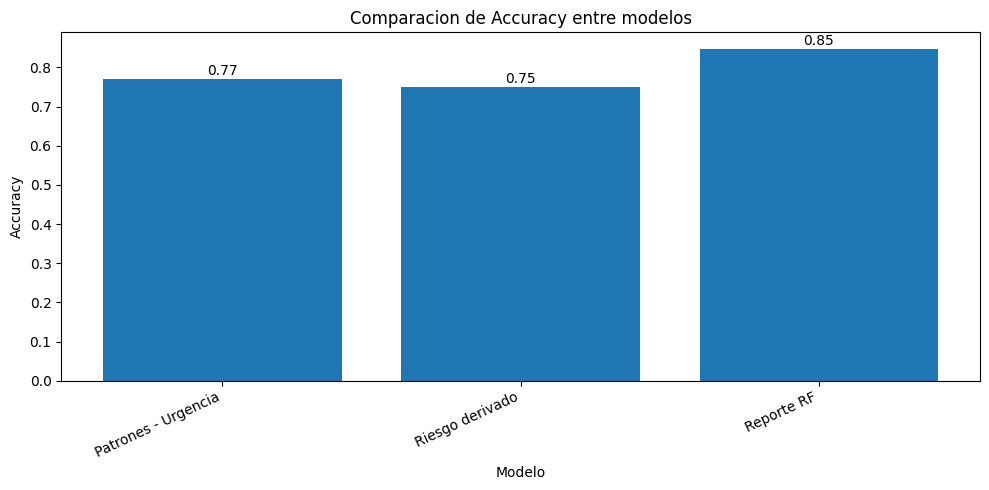

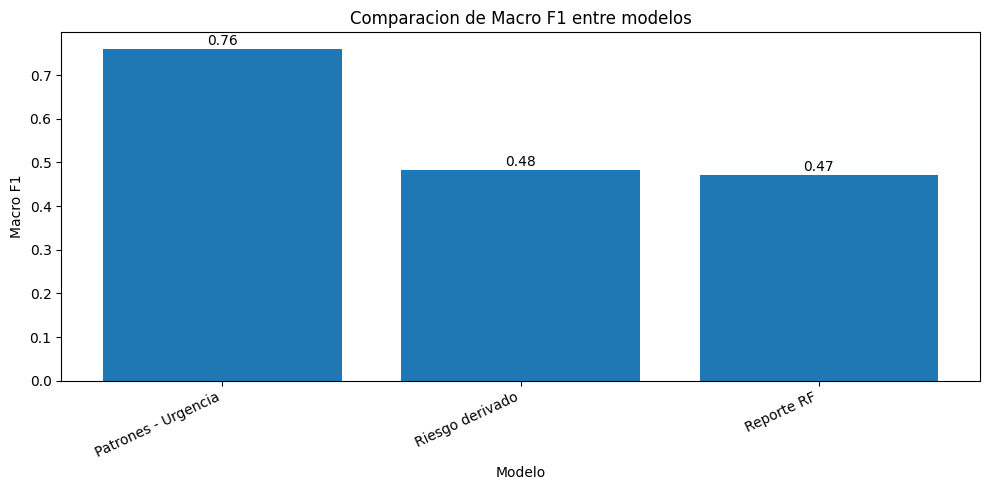

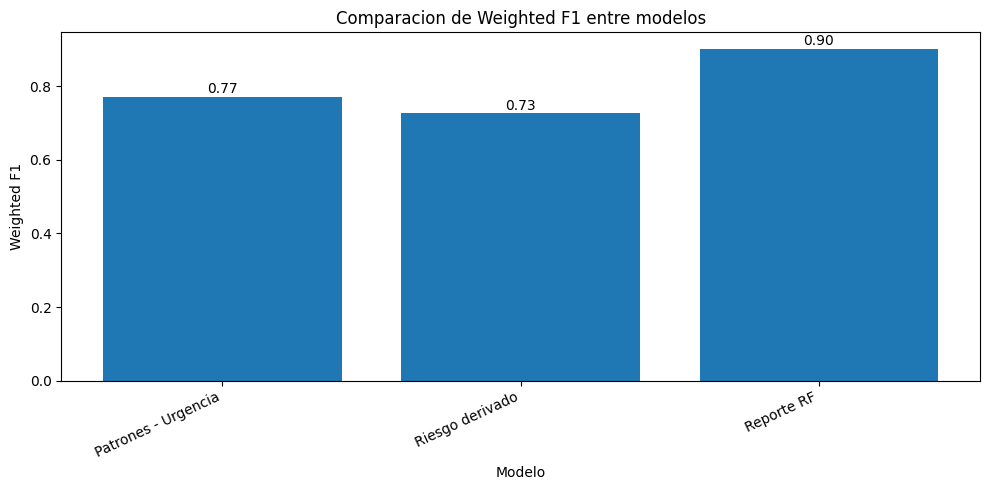

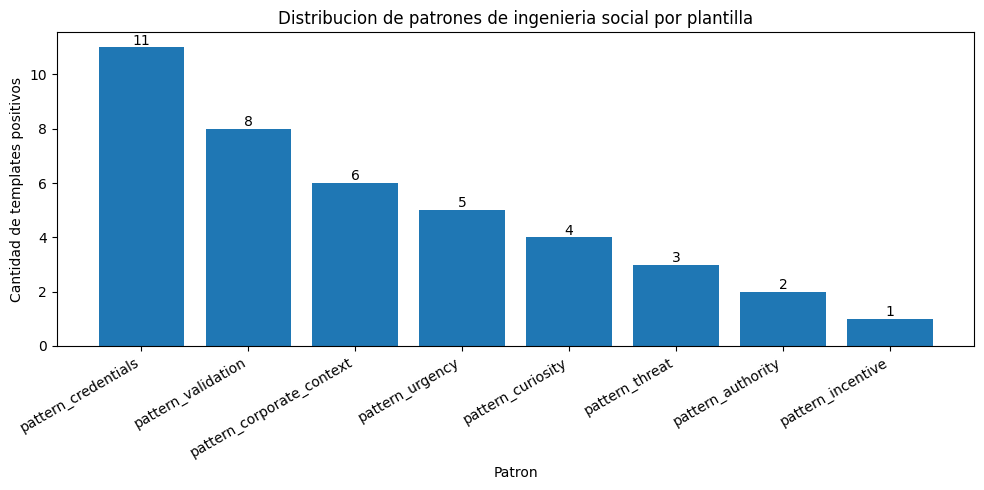

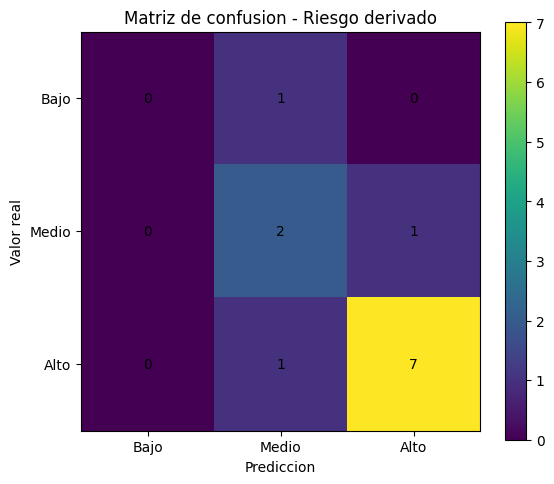

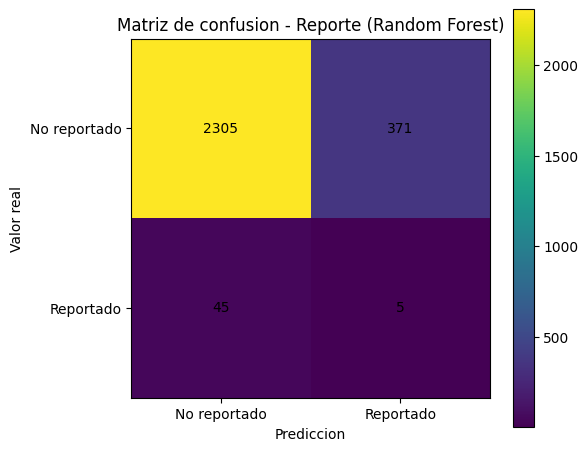

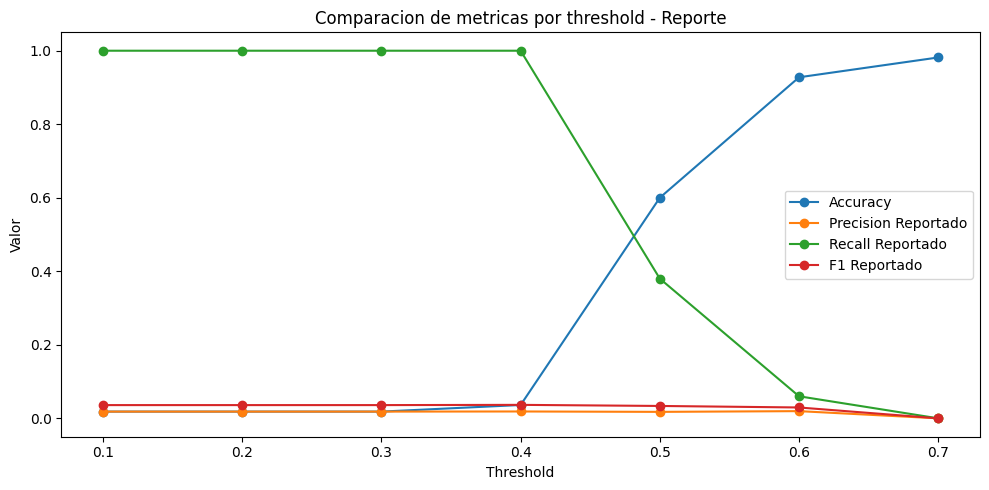

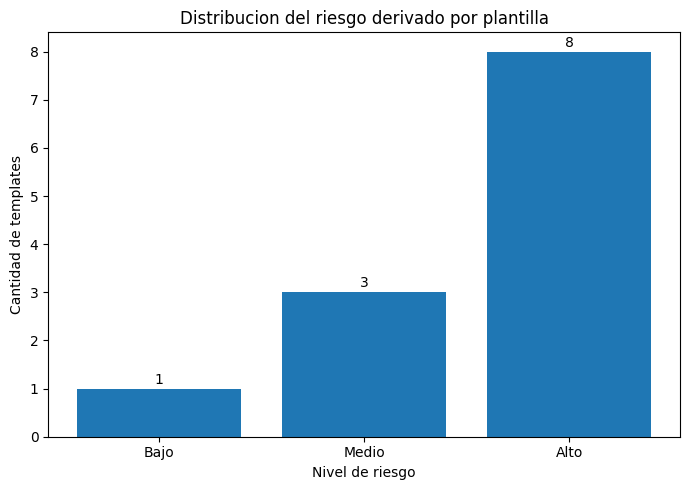

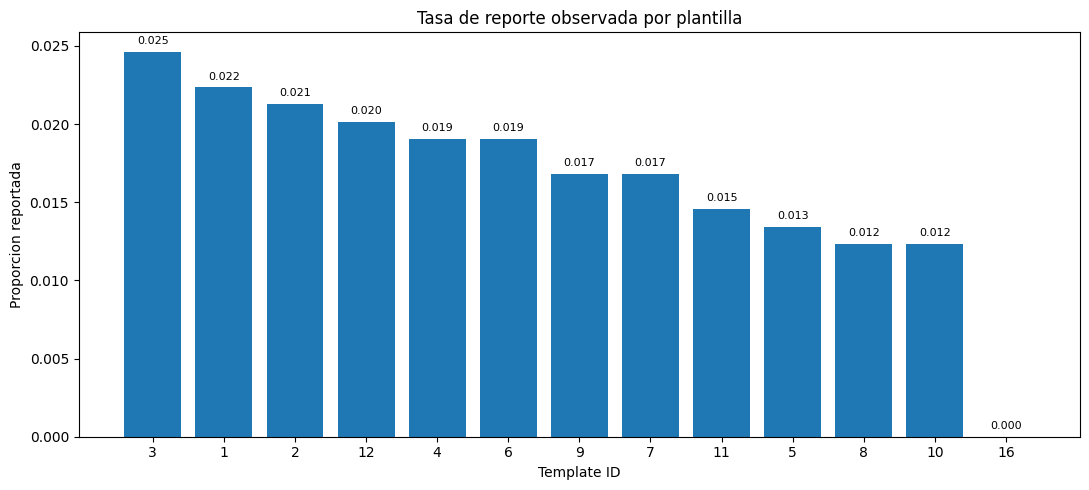

In [40]:
# =========================================================
# GRAFICAS FINALES COMPARATIVAS DE RESULTADOS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. COMPARACION GENERAL DE MODELOS
# Ajusta o amplia estos valores si deseas agregar mas modelos
# ---------------------------------------------------------
df_model_metrics = pd.DataFrame({
    "modelo": [
        "Patrones - Urgencia",
        "Riesgo derivado",
        "Reporte RF"
    ],
    "accuracy": [
        0.77,      # leave-one-out de pattern_urgency
        0.75,      # risk rule
        0.8474     # reported rf
    ],
    "macro_f1": [
        0.76,      # macro avg aproximado mostrado en pattern_urgency
        0.4821,    # risk rule
        0.4704     # reported rf
    ],
    "weighted_f1": [
        0.77,      # weighted avg aproximado mostrado en pattern_urgency
        0.7262,    # risk rule
        0.9008     # reported rf
    ]
})

# Accuracy
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["accuracy"])
plt.title("Comparacion de Accuracy entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

# Macro F1
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["macro_f1"])
plt.title("Comparacion de Macro F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["macro_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

# Weighted F1
plt.figure(figsize=(10, 5))
plt.bar(df_model_metrics["modelo"], df_model_metrics["weighted_f1"])
plt.title("Comparacion de Weighted F1 entre modelos")
plt.xlabel("Modelo")
plt.ylabel("Weighted F1")
plt.xticks(rotation=25, ha="right")
for i, v in enumerate(df_model_metrics["weighted_f1"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. DISTRIBUCION FINAL DE PATRONES DE INGENIERIA SOCIAL
# Usa df_templates_final si ya lo tienes
# ---------------------------------------------------------
pattern_cols = [
    "pattern_urgency",
    "pattern_authority",
    "pattern_credentials",
    "pattern_threat",
    "pattern_validation",
    "pattern_incentive",
    "pattern_curiosity",
    "pattern_corporate_context"
]

pattern_summary = pd.DataFrame({
    "pattern": pattern_cols,
    "positives": [df_templates_final[c].sum() for c in pattern_cols]
}).sort_values("positives", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(pattern_summary["pattern"], pattern_summary["positives"])
plt.title("Distribucion de patrones de ingenieria social por plantilla")
plt.xlabel("Patron")
plt.ylabel("Cantidad de templates positivos")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(pattern_summary["positives"]):
    plt.text(i, v + 0.1, f"{int(v)}", ha="center")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. MATRIZ DE CONFUSION - RIESGO DERIVADO
# Basada en los resultados obtenidos:
# Real_Bajo -> 1 caso
# Real_Medio -> 3 casos
# Real_Alto -> 8 casos
# Ajusta si tus valores finales cambiaron
# ---------------------------------------------------------
cm_risk = np.array([
    [0, 1, 0],   # Real Bajo
    [0, 2, 1],   # Real Medio
    [0, 1, 7]    # Real Alto
])

labels_risk = ["Bajo", "Medio", "Alto"]

plt.figure(figsize=(6, 5))
plt.imshow(cm_risk, interpolation="nearest")
plt.title("Matriz de confusion - Riesgo derivado")
plt.colorbar()
plt.xticks(np.arange(len(labels_risk)), labels_risk)
plt.yticks(np.arange(len(labels_risk)), labels_risk)
plt.xlabel("Prediccion")
plt.ylabel("Valor real")

for i in range(cm_risk.shape[0]):
    for j in range(cm_risk.shape[1]):
        plt.text(j, i, str(cm_risk[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 4. MATRIZ DE CONFUSION - REPORTE RANDOM FOREST
# Tomada de tu salida final
# ---------------------------------------------------------
cm_report_rf = np.array([
    [2305, 371],  # Real_NoReportado
    [45,   5]     # Real_Reportado
])

labels_report = ["No reportado", "Reportado"]

plt.figure(figsize=(6, 5))
plt.imshow(cm_report_rf, interpolation="nearest")
plt.title("Matriz de confusion - Reporte (Random Forest)")
plt.colorbar()
plt.xticks(np.arange(len(labels_report)), labels_report)
plt.yticks(np.arange(len(labels_report)), labels_report)
plt.xlabel("Prediccion")
plt.ylabel("Valor real")

for i in range(cm_report_rf.shape[0]):
    for j in range(cm_report_rf.shape[1]):
        plt.text(j, i, str(cm_report_rf[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. COMPARACION DE UMBRALES - MODELO DE REPORTE LINEAL
# Usa tus resultados reales de df_thresholds si ya existen
# ---------------------------------------------------------
df_thresholds_plot = pd.DataFrame({
    "threshold": [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70],
    "accuracy": [0.018342, 0.018342, 0.018342, 0.036317, 0.600147, 0.927733, 0.981658],
    "precision_reported": [0.018342, 0.018342, 0.018342, 0.018678, 0.017625, 0.019608, 0.000000],
    "recall_reported": [1.00, 1.00, 1.00, 1.00, 0.38, 0.06, 0.00],
    "f1_reported": [0.036023, 0.036023, 0.036023, 0.036670, 0.033688, 0.029557, 0.000000]
})

plt.figure(figsize=(10, 5))
plt.plot(df_thresholds_plot["threshold"], df_thresholds_plot["accuracy"], marker="o", label="Accuracy")
plt.plot(df_thresholds_plot["threshold"], df_thresholds_plot["precision_reported"], marker="o", label="Precision Reportado")
plt.plot(df_thresholds_plot["threshold"], df_thresholds_plot["recall_reported"], marker="o", label="Recall Reportado")
plt.plot(df_thresholds_plot["threshold"], df_thresholds_plot["f1_reported"], marker="o", label="F1 Reportado")
plt.title("Comparacion de metricas por threshold - Reporte")
plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 6. DISTRIBUCION DEL RIESGO DERIVADO POR PLANTILLA
# Usa df_risk_rules si ya lo tienes
# ---------------------------------------------------------
risk_dist = (
    df_risk_rules["risk_label_rule"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"], fill_value=0)
)

plt.figure(figsize=(7, 5))
plt.bar(risk_dist.index, risk_dist.values)
plt.title("Distribucion del riesgo derivado por plantilla")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de templates")
for i, v in enumerate(risk_dist.values):
    plt.text(i, v + 0.1, str(int(v)), ha="center")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 7. TASA DE REPORTE POR TEMPLATE
# Usa df_report si ya lo tienes
# ---------------------------------------------------------
df_report_sorted = df_report.sort_values("reported", ascending=False).copy()

plt.figure(figsize=(11, 5))
plt.bar(df_report_sorted["template_id"].astype(str), df_report_sorted["reported"])
plt.title("Tasa de reporte observada por plantilla")
plt.xlabel("Template ID")
plt.ylabel("Proporcion reportada")
for i, v in enumerate(df_report_sorted["reported"]):
    plt.text(i, v + 0.0005, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

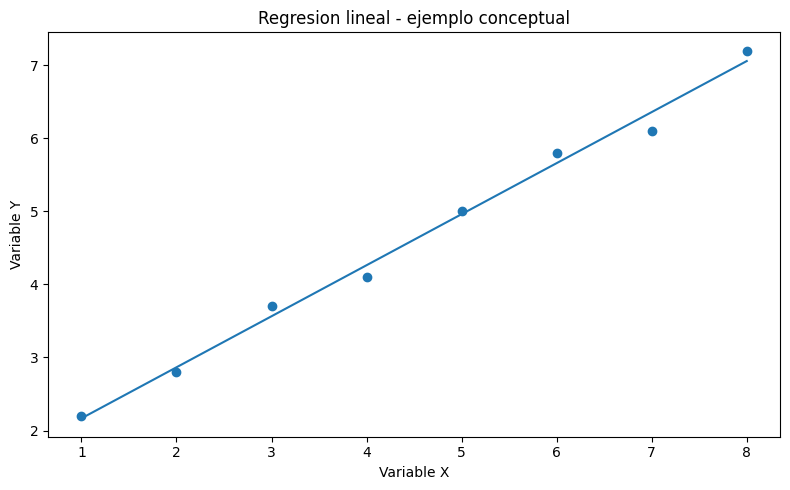

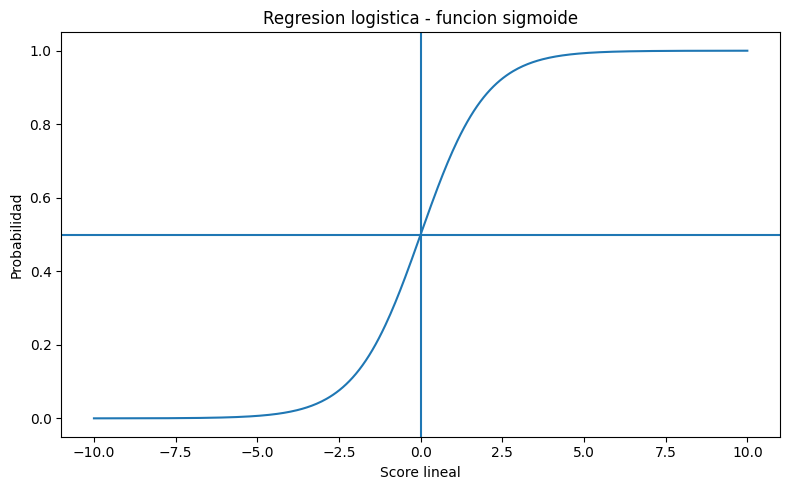

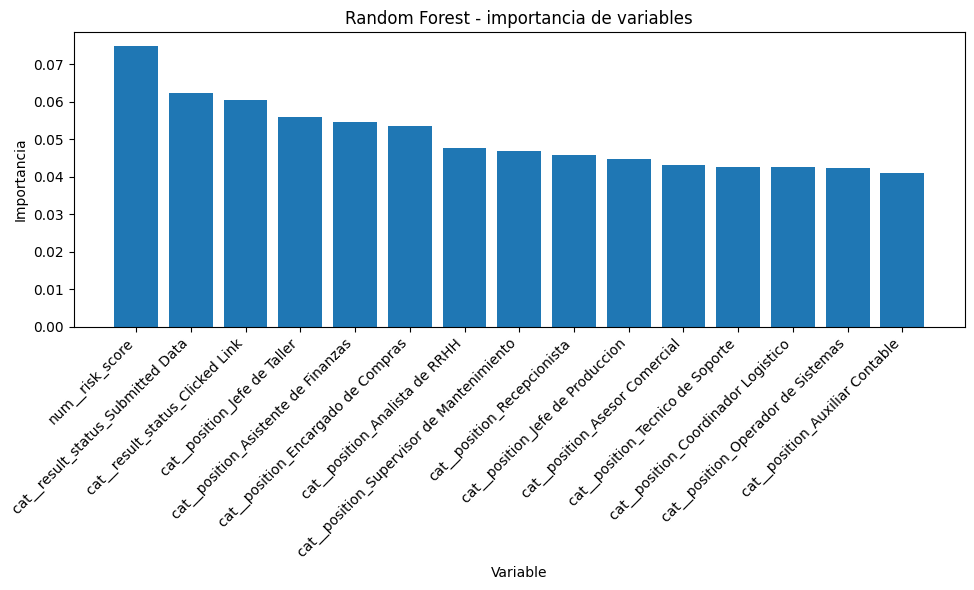

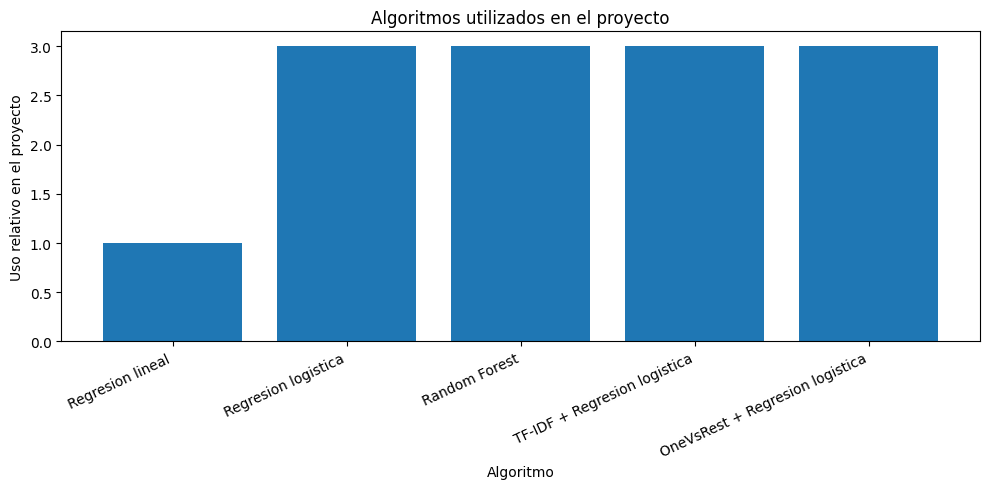

In [42]:
# =========================================================
# GRAFICAS DE LOS ALGORITMOS UTILIZADOS
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. REGRESION LINEAL - EJEMPLO CONCEPTUAL
# ---------------------------------------------------------
x = np.array([1, 2, 3, 4, 5, 6, 7, 8], dtype=float)
y = np.array([2.2, 2.8, 3.7, 4.1, 5.0, 5.8, 6.1, 7.2], dtype=float)

coef = np.polyfit(x, y, 1)
y_line = coef[0] * x + coef[1]

plt.figure(figsize=(8, 5))
plt.scatter(x, y)
plt.plot(x, y_line)
plt.title("Regresion lineal - ejemplo conceptual")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. REGRESION LOGISTICA - CURVA SIGMOIDE
# ---------------------------------------------------------
z = np.linspace(-10, 10, 400)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid)
plt.axhline(0.5)
plt.axvline(0)
plt.title("Regresion logistica - funcion sigmoide")
plt.xlabel("Score lineal")
plt.ylabel("Probabilidad")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. RANDOM FOREST - IMPORTANCIA DE VARIABLES
# Requiere que ya exista model_report_rf y df_report_rf en tu notebook
# ---------------------------------------------------------
try:
    prep_rf = model_report_rf.named_steps["prep"]
    clf_rf = model_report_rf.named_steps["clf"]

    feature_names_rf = prep_rf.get_feature_names_out()
    importances_rf = clf_rf.feature_importances_

    df_rf_imp = pd.DataFrame({
        "feature": feature_names_rf,
        "importance": importances_rf
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.bar(df_rf_imp["feature"], df_rf_imp["importance"])
    plt.title("Random Forest - importancia de variables")
    plt.xlabel("Variable")
    plt.ylabel("Importancia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("No se pudo graficar la importancia de Random Forest.")
    print("Asegurate de haber ejecutado primero el modelo model_report_rf.")
    print("Detalle:", e)


# ---------------------------------------------------------
# 4. COMPARACION GENERAL DE ALGORITMOS USADOS
# Puedes ajustar los nombres si deseas
# ---------------------------------------------------------
algorithms = [
    "Regresion lineal",
    "Regresion logistica",
    "Random Forest",
    "TF-IDF + Regresion logistica",
    "OneVsRest + Regresion logistica"
]

usage_score = [1, 3, 3, 3, 3]

plt.figure(figsize=(10, 5))
plt.bar(algorithms, usage_score)
plt.title("Algoritmos utilizados en el proyecto")
plt.xlabel("Algoritmo")
plt.ylabel("Uso relativo en el proyecto")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()